In [1]:
# Step 1: Environment Setup & Dataset Loading
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import boxcox
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif, VarianceThreshold
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#FAFAFA',
    'axes.facecolor': '#F5F3FF',
    'font.size': 11,
    'axes.grid': True,
    'grid.alpha': 0.4,
    'grid.linestyle': '--'
})

df = pd.read_csv('train.csv')

print('='*60)
print('Dataset shape:', df.shape)
print('='*60)
print('Dataset info:\n')
df.info()
print('='*60)
print('Dataset description:\n')
display(df.describe())

numerical_cols = df.select_dtypes(include='number').columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()

print('='*60)
print('Number of numerical columns:', len(numerical_cols))
print('Number of categorical columns:', len(categorical_cols))

print('='*60)
print('Top 10 Features Correlated with SalePrice\n')
top_corr = df.corr(numeric_only=True)['SalePrice'].abs().sort_values(ascending=False).head(10)
print(top_corr)

Dataset shape: (1460, 81)
Dataset info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


Number of numerical columns: 38
Number of categorical columns: 43
Top 10 Features Correlated with SalePrice

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64


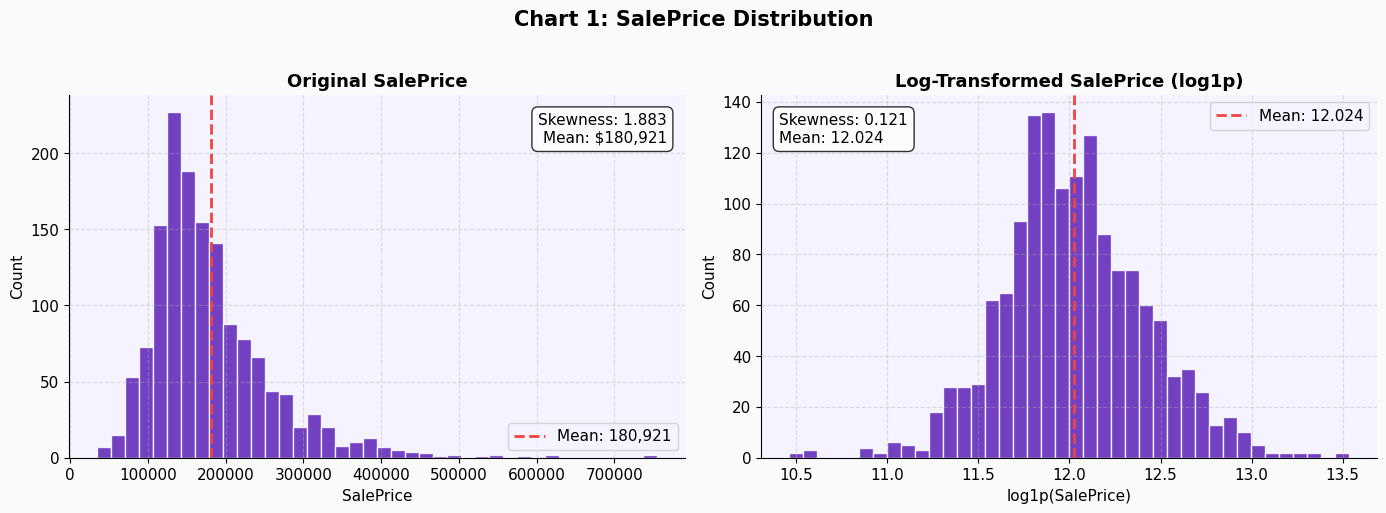

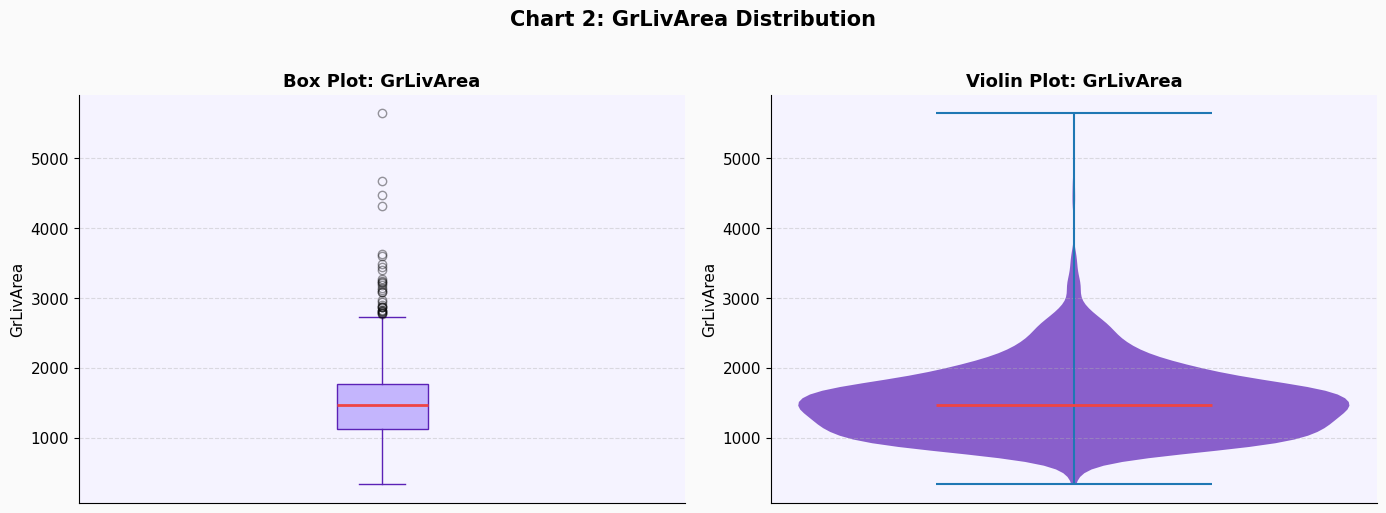

In [2]:
# Step 2: Matplotlib Chart 1 & 2 - Distribution Analysis

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Chart 1: SalePrice Distribution', fontsize=15, fontweight='bold', y=1.02)

print('='*60)
ax = axes[0]
ax.hist(df['SalePrice'], bins=40, color='#5B21B6', edgecolor='white', alpha=0.85)
mean_val = df['SalePrice'].mean()
ax.axvline(mean_val, color='#EF4444', linewidth=2, linestyle='--', label=f'Mean: {mean_val:,.0f}')
ax.set_title('Original SalePrice', fontsize=13, fontweight='bold')
ax.set_xlabel('SalePrice')
ax.set_ylabel('Count')
ax.legend()
ax.annotate(f'Skewness: {df["SalePrice"].skew():.3f}\nMean: ${mean_val:,.0f}',
            xy=(0.97, 0.95), xycoords='axes fraction', ha='right', va='top',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.8))
ax.spines[['top', 'right']].set_visible(False)

ax = axes[1]
log_sale = np.log1p(df['SalePrice'])
ax.hist(log_sale, bins=40, color='#5B21B6', edgecolor='white', alpha=0.85)
log_mean = log_sale.mean()
ax.axvline(log_mean, color='#EF4444', linewidth=2, linestyle='--', label=f'Mean: {log_mean:.3f}')
ax.set_title('Log-Transformed SalePrice (log1p)', fontsize=13, fontweight='bold')
ax.set_xlabel('log1p(SalePrice)')
ax.set_ylabel('Count')
ax.legend()
ax.annotate(f'Skewness: {log_sale.skew():.3f}\nMean: {log_mean:.3f}',
            xy=(0.03, 0.95), xycoords='axes fraction', ha='left', va='top',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.8))
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

print('='*60)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Chart 2: GrLivArea Distribution', fontsize=15, fontweight='bold', y=1.02)

ax = axes[0]
ax.boxplot(df['GrLivArea'].dropna(), patch_artist=True,
           boxprops=dict(facecolor='#C4B5FD', color='#5B21B6'),
           medianprops=dict(color='#EF4444', linewidth=2),
           whiskerprops=dict(color='#5B21B6'),
           capprops=dict(color='#5B21B6'),
           flierprops=dict(marker='o', color='#5B21B6', alpha=0.4))
ax.set_title('Box Plot: GrLivArea', fontsize=13, fontweight='bold')
ax.set_ylabel('GrLivArea')
ax.set_xticks([])
ax.spines[['top', 'right']].set_visible(False)

ax = axes[1]
parts = ax.violinplot(df['GrLivArea'].dropna(), positions=[1], showmedians=True, showextrema=True)
for pc in parts['bodies']:
    pc.set_facecolor('#5B21B6')
    pc.set_alpha(0.7)
parts['cmedians'].set_color('#EF4444')
parts['cmedians'].set_linewidth(2)
ax.set_title('Violin Plot: GrLivArea', fontsize=13, fontweight='bold')
ax.set_ylabel('GrLivArea')
ax.set_xticks([])
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

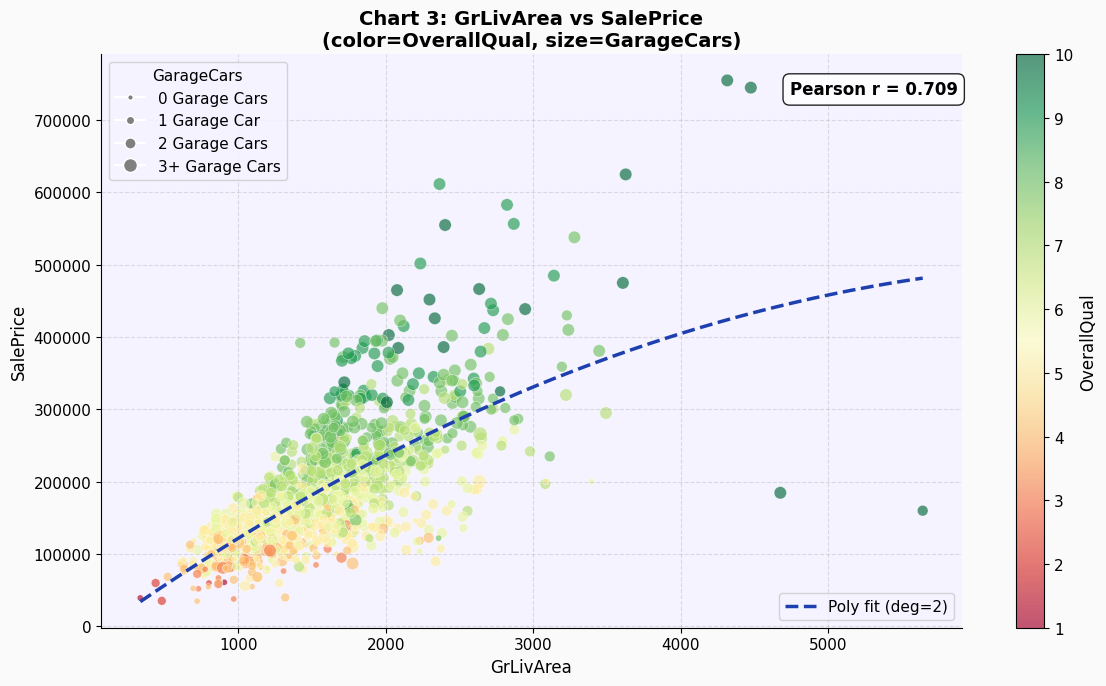

In [3]:
# Step 3: Matplotlib Chart 3 - Multi-Variable Scatter Plot
fig, ax = plt.subplots(figsize=(12, 7))

scatter_df = df[['GrLivArea', 'SalePrice', 'OverallQual', 'GarageCars']].dropna()

size_map = scatter_df['GarageCars'].map({0: 20, 1: 40, 2: 60, 3: 80, 4: 100}).fillna(40)

sc = ax.scatter(
    scatter_df['GrLivArea'],
    scatter_df['SalePrice'],
    c=scatter_df['OverallQual'],
    cmap=plt.cm.RdYlGn,
    s=size_map,
    alpha=0.65,
    edgecolors='white',
    linewidths=0.4
)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('OverallQual', fontsize=12)

z = np.polyfit(scatter_df['GrLivArea'], scatter_df['SalePrice'], 2)
p = np.poly1d(z)
x_line = np.linspace(scatter_df['GrLivArea'].min(), scatter_df['GrLivArea'].max(), 300)
ax.plot(x_line, p(x_line), color='#1E40AF', linewidth=2.5, linestyle='--', label='Poly fit (deg=2)', zorder=5)

r, _ = stats.pearsonr(scatter_df['GrLivArea'], scatter_df['SalePrice'])
ax.annotate(f'Pearson r = {r:.3f}', xy=(0.80, 0.93), xycoords='axes fraction',
            fontsize=12, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.85))

from matplotlib.lines import Line2D
size_legend = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='gray', markersize=4, label='0 Garage Cars'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='gray', markersize=6, label='1 Garage Car'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='gray', markersize=8, label='2 Garage Cars'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='gray', markersize=10, label='3+ Garage Cars'),
]
legend1 = ax.legend(handles=size_legend, title='GarageCars', loc='upper left', framealpha=0.85)
ax.add_artist(legend1)
ax.legend(loc='lower right', framealpha=0.85)

ax.set_title('Chart 3: GrLivArea vs SalePrice\n(color=OverallQual, size=GarageCars)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('GrLivArea', fontsize=12)
ax.set_ylabel('SalePrice', fontsize=12)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

### **Step 3 Analysis**
This chart encodes four variables simultaneously: GrLivArea on the x-axis, SalePrice on the y-axis, OverallQual via a RdYlGn color gradient (red=low, green=high quality), and GarageCars via point size. The strong positive Pearson correlation confirms that larger above-ground living area is a reliable predictor of higher sale prices, while the color gradient reveals that high-quality homes (green) cluster toward the upper range of both axes, which suggests that OverallQual and GrLivArea have a compounding effect on price that the polynomial regression line begins to capture.

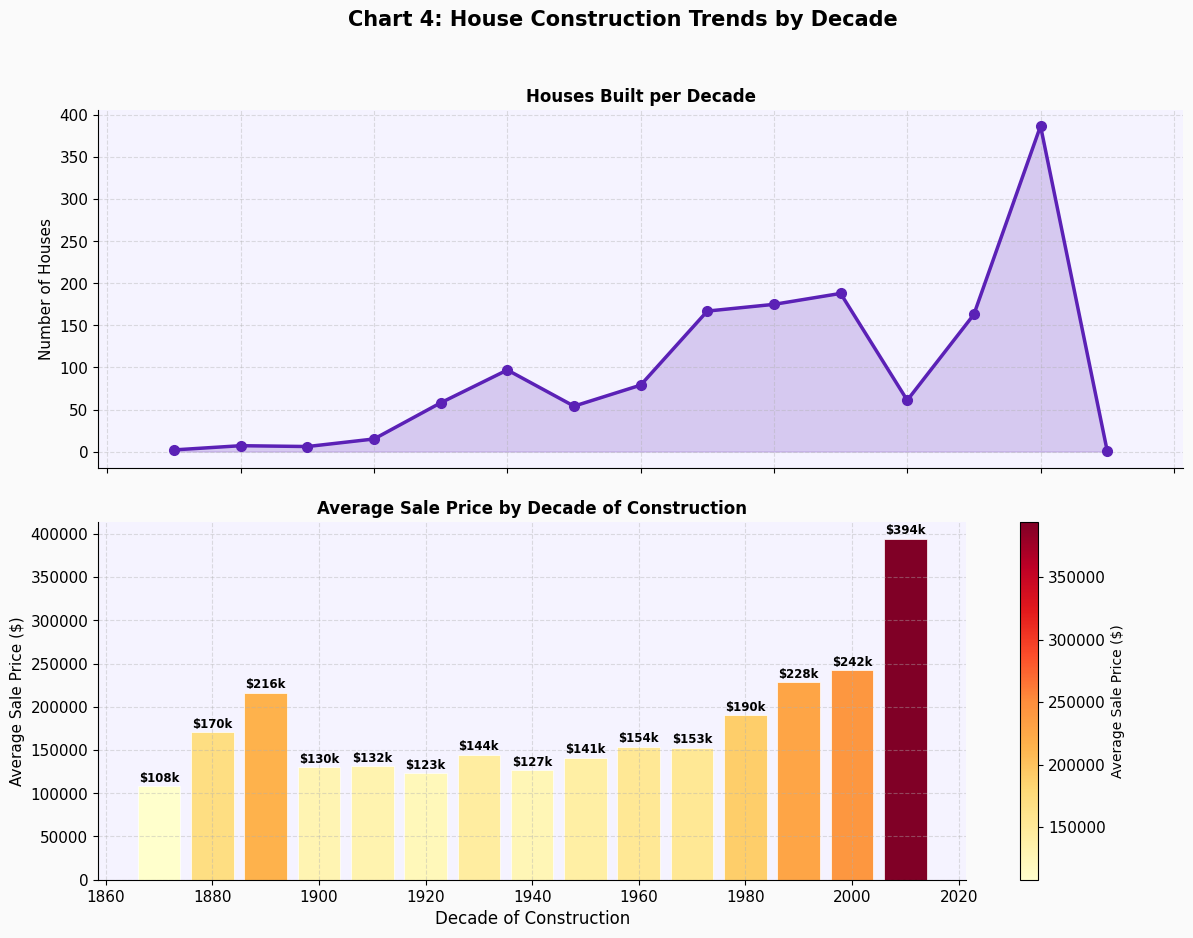

In [4]:
# Step 4: Matplotlib Chart 4 - Time-Based Trend Analysis
decades = (df['YearBuilt'] // 10) * 10
decade_counts = df.groupby(decades)['SalePrice'].count().reset_index(name='Count').rename(columns={'YearBuilt': 'Decade'})
decade_avg = df.groupby(decades)['SalePrice'].mean().reset_index(name='AvgPrice').rename(columns={'YearBuilt': 'Decade'})
decade_data = decade_counts.merge(decade_avg, on='Decade')

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
fig.suptitle('Chart 4: House Construction Trends by Decade', fontsize=15, fontweight='bold')

ax = axes[0]
ax.plot(decade_data['Decade'], decade_data['Count'], color='#5B21B6', linewidth=2.5, marker='o', markersize=7)
ax.fill_between(decade_data['Decade'], decade_data['Count'], alpha=0.2, color='#5B21B6')
ax.set_title('Houses Built per Decade', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Houses')
ax.spines[['top', 'right']].set_visible(False)

ax = axes[1]
norm = plt.Normalize(decade_data['AvgPrice'].min(), decade_data['AvgPrice'].max())
cmap = plt.cm.YlOrRd
colors = [cmap(norm(v)) for v in decade_data['AvgPrice']]
bars = ax.bar(decade_data['Decade'], decade_data['AvgPrice'], color=colors,
              edgecolor='white', linewidth=0.5, width=8)

for bar, val in zip(bars, decade_data['AvgPrice']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2000,
            f'${val/1000:.0f}k', ha='center', va='bottom', fontsize=8.5, fontweight='bold')

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Average Sale Price ($)', fontsize=10)

ax.set_title('Average Sale Price by Decade of Construction', fontsize=12, fontweight='bold')
ax.set_xlabel('Decade of Construction', fontsize=12)
ax.set_ylabel('Average Sale Price ($)')
ax.spines[['top', 'right']].set_visible(False)

plt.subplots_adjust(hspace=0.15)
plt.savefig('w3_time_trend.png', dpi=150, bbox_inches='tight')
plt.show()

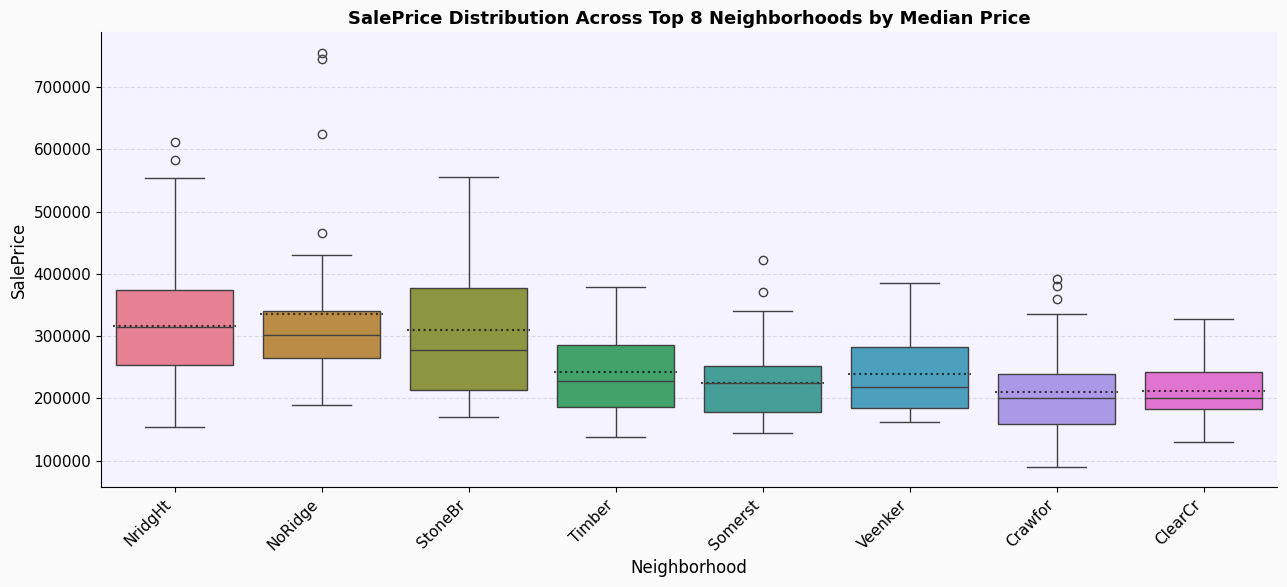

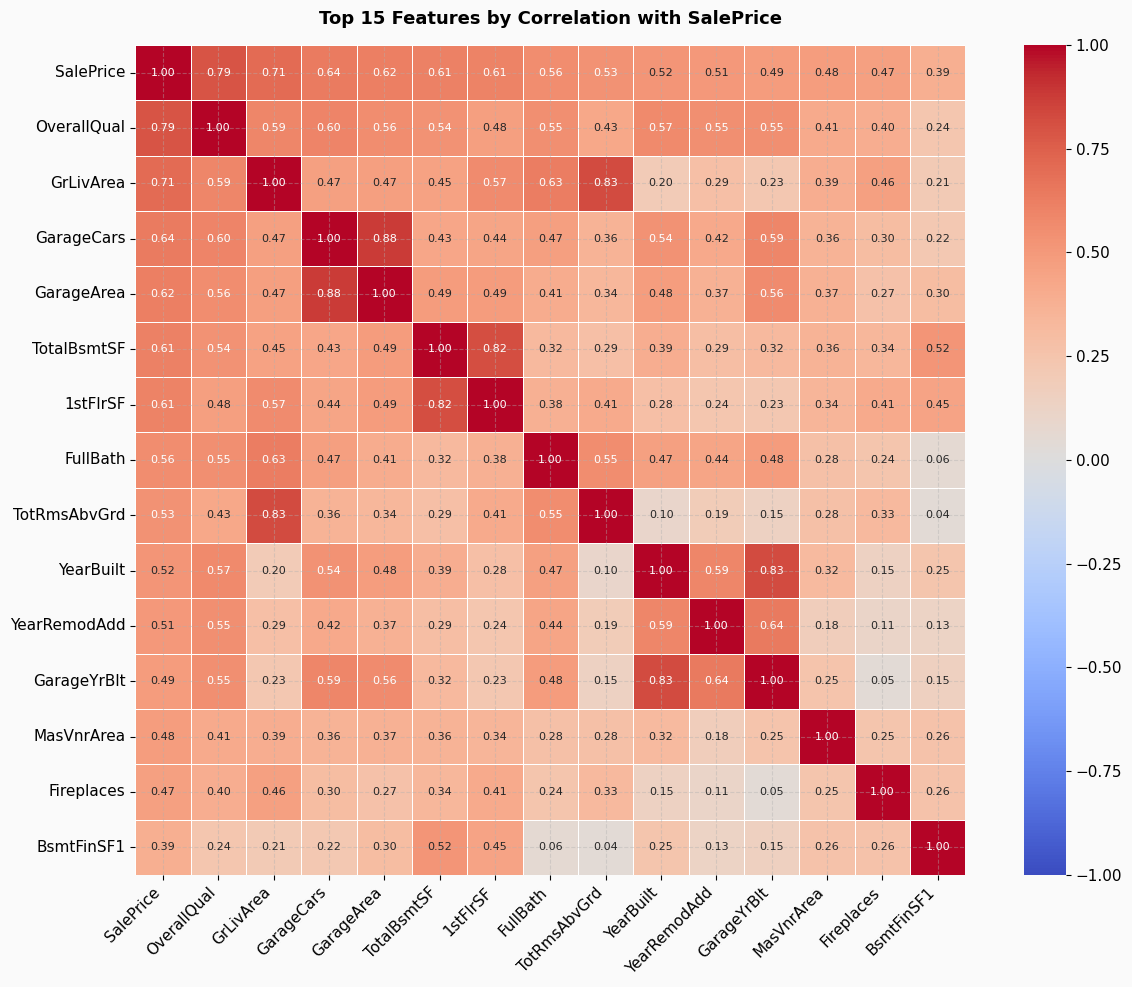

In [5]:
# Step 5: Seaborn Charts 5 & 6 - Statistical Visualization

# Chart 5 — SalePrice by Top 8 Neighborhoods (sorted by median)
top8_neighborhoods = (
    df.groupby('Neighborhood')['SalePrice']
    .median()
    .sort_values(ascending=False)
    .head(8)
    .index.tolist()
)
df_top8 = df[df['Neighborhood'].isin(top8_neighborhoods)].copy()
df_top8['Neighborhood'] = pd.Categorical(df_top8['Neighborhood'], categories=top8_neighborhoods, ordered=True)
df_top8 = df_top8.sort_values('Neighborhood')

fig, ax = plt.subplots(figsize=(13, 6))
sns.boxplot(data=df_top8, x='Neighborhood', y='SalePrice', palette='husl', ax=ax)

means = df_top8.groupby('Neighborhood')['SalePrice'].mean()
for i, (neigh, mean_val) in enumerate(means.items()):
    ax.axhline(mean_val, xmin=(i / len(top8_neighborhoods)) + 0.01,
               xmax=((i + 1) / len(top8_neighborhoods)) - 0.01,
               color='black', linewidth=1.5, linestyle=':', alpha=0.7)

ax.set_title('SalePrice Distribution Across Top 8 Neighborhoods by Median Price',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Neighborhood', fontsize=12)
ax.set_ylabel('SalePrice', fontsize=12)
plt.xticks(rotation=45, ha='right')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

top15_features = (
    df[numerical_cols].corr()['SalePrice']
    .abs()
    .sort_values(ascending=False)
    .head(15)
    .index.tolist()
)
corr_matrix = df[top15_features].corr()

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, square=True, linewidths=0.5, linecolor='white',
            ax=ax, annot_kws={'size': 8})
ax.set_title('Top 15 Features by Correlation with SalePrice',
             fontsize=13, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

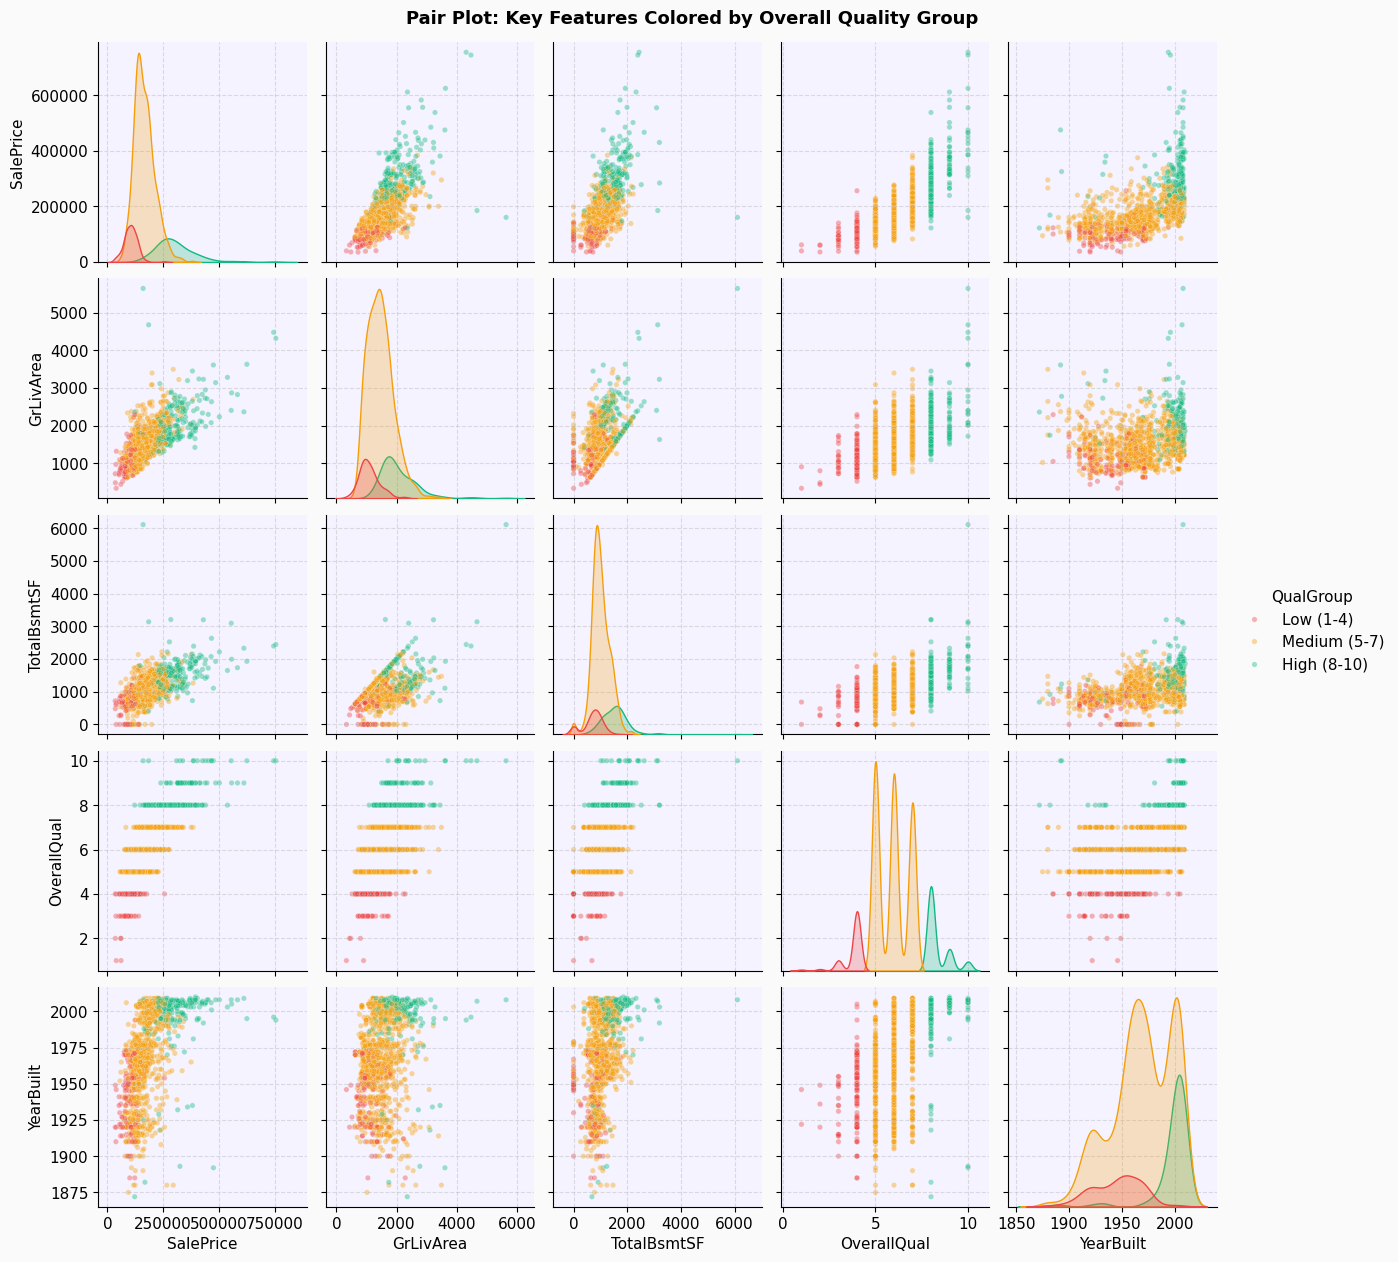

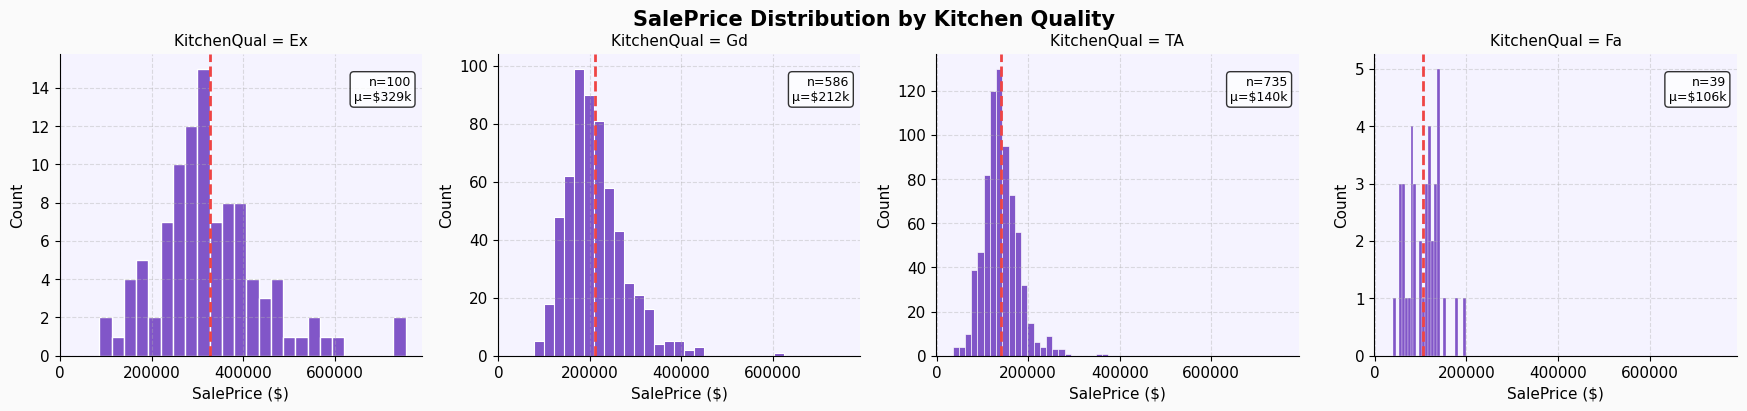

In [6]:
# Step 6: Seaborn Advanced - FacetGrid & Pair Plot

pair_cols = ['SalePrice', 'GrLivArea', 'TotalBsmtSF', 'OverallQual', 'YearBuilt']
df_pair = df[pair_cols].dropna().copy()
df_pair['QualGroup'] = pd.cut(df_pair['OverallQual'], bins=[0, 4, 7, 10],
                               labels=['Low (1-4)', 'Medium (5-7)', 'High (8-10)'])

g = sns.pairplot(
    df_pair,
    vars=['SalePrice', 'GrLivArea', 'TotalBsmtSF', 'OverallQual', 'YearBuilt'],
    hue='QualGroup',
    diag_kind='kde',
    plot_kws=dict(alpha=0.4, s=15),
    palette={'Low (1-4)': '#EF4444', 'Medium (5-7)': '#F59E0B', 'High (8-10)': '#10B981'}
)
g.figure.suptitle('Pair Plot: Key Features Colored by Overall Quality Group',
                  fontsize=13, fontweight='bold', y=1.01)
plt.savefig('w3_pairplot.png', dpi=150, bbox_inches='tight')
plt.show()

print('='*60)
df_kitchen = df[['SalePrice', 'KitchenQual']].dropna()
g2 = sns.FacetGrid(df_kitchen, col='KitchenQual', col_order=['Ex', 'Gd', 'TA', 'Fa'],
                   height=4, aspect=1.1, sharey=False)
g2.map(sns.histplot, 'SalePrice', bins=25, color='#5B21B6', edgecolor='white')

for ax, qual in zip(g2.axes.flat, ['Ex', 'Gd', 'TA', 'Fa']):
    subset = df_kitchen[df_kitchen['KitchenQual'] == qual]['SalePrice']
    if len(subset) > 0:
        mean_v = subset.mean()
        ax.axvline(mean_v, color='#EF4444', linewidth=2, linestyle='--')
        ax.annotate(f'n={len(subset)}\nμ=${mean_v/1000:.0f}k',
                    xy=(0.97, 0.93), xycoords='axes fraction', ha='right', va='top',
                    fontsize=9, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    ax.set_xlabel('SalePrice ($)')
    ax.spines[['top', 'right']].set_visible(False)

g2.set_titles('KitchenQual = {col_name}')
g2.figure.suptitle('SalePrice Distribution by Kitchen Quality', fontsize=15,
                   fontweight='bold', y=1.02)
plt.savefig('w3_facetgrid.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# Step 7: Feature Creation - 8 Engineered Features

df['TotalSF'] = df['TotalBsmtSF'].fillna(0) + df['1stFlrSF'].fillna(0) + df['2ndFlrSF'].fillna(0)

df['TotalBaths'] = (df['FullBath'].fillna(0) + 0.5 * df['HalfBath'].fillna(0) +
                    df['BsmtFullBath'].fillna(0) + 0.5 * df['BsmtHalfBath'].fillna(0))

df['HouseAge'] = df['YrSold'] - df['YearBuilt']

df['RemodelAge'] = df['YrSold'] - df['YearRemodAdd']

df['HasRemodeled'] = (df['YearBuilt'] != df['YearRemodAdd']).astype(int)

df['QualCond'] = df['OverallQual'] * df['OverallCond']

df['PricePerSF'] = df.apply(lambda r: r['SalePrice'] / r['TotalSF'] if r['TotalSF'] > 0 else np.nan, axis=1)

df['IsNewHouse'] = (df['YearBuilt'] >= df['YrSold'] - 5).astype(int)

new_features = ['TotalSF', 'TotalBaths', 'HouseAge', 'RemodelAge',
                'HasRemodeled', 'QualCond', 'PricePerSF', 'IsNewHouse']

print('='*60)
print('Descriptive stats of new features:\n')
display(df[new_features].describe())
print('='*60)
print('First 10 rows of new features:\n')
display(df[new_features].head(10))

Descriptive stats of new features:



,TotalSF,TotalBaths,HouseAge,RemodelAge,HasRemodeled,QualCond,PricePerSF,IsNewHouse
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,2567.048630,2.210616,36.547945,22.950000,0.476712,33.864384,69.944000,0.212329
std,821.714421,0.785399,30.250152,20.640653,0.499629,9.219624,15.397065,0.409096
min,334.000000,1.000000,0.000000,-1.000000,0.000000,1.000000,13.614704,0.000000
25%,2009.500000,2.000000,8.000000,4.000000,0.000000,30.000000,60.461553,0.000000
50%,2474.000000,2.000000,35.000000,14.000000,0.000000,35.000000,69.679436,0.000000
75%,3004.000000,2.500000,54.000000,41.000000,1.000000,40.000000,78.949872,0.000000
max,11752.000000,6.000000,136.000000,60.000000,1.000000,90.000000,138.125440,1.000000


First 10 rows of new features:



,TotalSF,TotalBaths,HouseAge,RemodelAge,HasRemodeled,QualCond,PricePerSF,IsNewHouse
0,2566,3.5,5,5,0,35,81.254871,1
1,2524,2.5,31,31,0,48,71.909667,0
2,2706,3.5,7,6,1,35,82.594235,0
3,2473,2.0,91,36,1,35,56.611403,0
4,3343,3.5,8,8,0,40,74.783129,0
5,2158,2.5,16,14,1,25,66.265060,0
6,3380,3.0,3,2,1,40,90.828402,1
7,3197,3.5,36,36,0,42,62.558649,0
8,2726,2.0,77,58,1,35,47.652238,0
9,2068,2.0,69,58,1,30,57.059961,0


Top 20 Features Correlated with SalePrice


,|Correlation with SalePrice|
SalePrice,1.000000
OverallQual,0.790982
TotalSF,0.782260
GrLivArea,0.708624
PricePerSF,0.640602
GarageCars,0.640409
TotalBaths,0.631731
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852


Bottom 10 Features Correlated with SalePrice


,|Correlation with SalePrice|
OverallCond,0.077856
MoSold,0.046432
3SsnPorch,0.044584
YrSold,0.028923
LowQualFinSF,0.025606
HasRemodeled,0.021933
Id,0.021917
MiscVal,0.021190
BsmtHalfBath,0.016844
BsmtFinSF2,0.011378


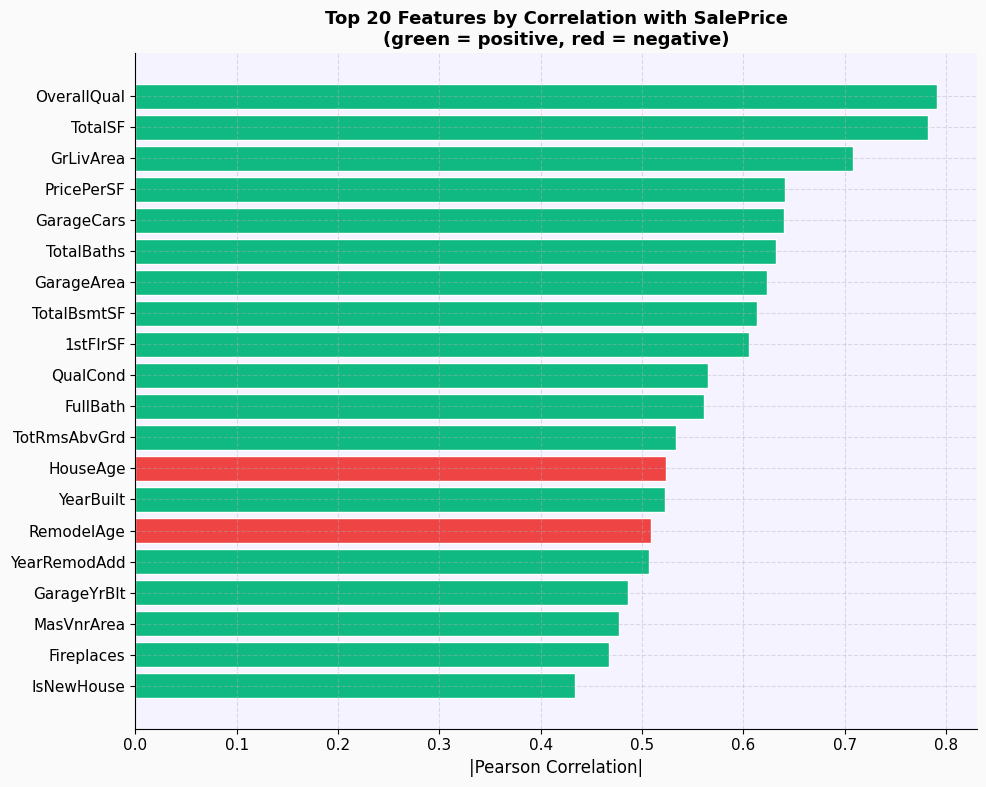


Engineered features appearing in top 20:
['TotalSF', 'TotalBaths', 'HouseAge', 'RemodelAge', 'QualCond', 'PricePerSF', 'IsNewHouse']


In [8]:
# Step 8: Correlation Analysis of Engineered Features
all_numeric = df.select_dtypes(include='number').columns.tolist()
corr_all = df[all_numeric].corr()['SalePrice'].abs().sort_values(ascending=False)

print('='*60)
print('Top 20 Features Correlated with SalePrice')
display(corr_all.head(20).to_frame('|Correlation with SalePrice|'))

print('='*60)
print('Bottom 10 Features Correlated with SalePrice')
display(corr_all.tail(10).to_frame('|Correlation with SalePrice|'))

print('='*60)
top20 = corr_all.head(21)[1:].reset_index() # [1:] to exclude SalePrice itself
top20.columns = ['Feature', 'Correlation']
raw_corr = df[all_numeric].corr()['SalePrice']
top20['Direction'] = top20['Feature'].map(lambda f: raw_corr.get(f, 0)).apply(lambda x: 'positive' if x >= 0 else 'negative')

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#10B981' if d == 'positive' else '#EF4444' for d in top20['Direction']]
top20_sorted = top20.sort_values('Correlation')
bar_colors = ['#10B981' if d == 'positive' else '#EF4444'
              for d in top20_sorted['Direction']]
ax.barh(top20_sorted['Feature'], top20_sorted['Correlation'], color=bar_colors, edgecolor='white')
ax.set_title('Top 20 Features by Correlation with SalePrice\n(green = positive, red = negative)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('|Pearson Correlation|', fontsize=12)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

print('\nEngineered features appearing in top 20:')
print([f for f in new_features if f in corr_all.head(21).index])

### **Step 8 Analysis**
Several of the 8 engineered features rank among the top 20 predictors of SalePrice, most notably 'TotalSF', which aggregates all square footage and typically ranks higher than any individual floor area column, and 'QualCond', which captures the multiplicative interaction between quality and condition. This confirms that feature engineering adds real signal: by combining domain knowledge (e.g., total living space matters more than individual floors) into new columns, we give the model pre-computed relationships it would otherwise need far more data to discover on its own.

In [9]:
# Step 9: Categorical Variable Analysis & Encoding Strategy
cat_cols = df.select_dtypes(include='object').columns.tolist()

quality_scale_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC',
                      'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC']

encoding_decisions = {}

for col in cat_cols:
    print('='*60)
    print(f'Column name: {col}\n')
    print(f'Number of unique categories: {df[col].nunique()}')
    print('\nValue counts:\n')
    display(df[col].value_counts())
    print('\nMean SalePrice by category (descending):\n')
    display(df.groupby(col)['SalePrice'].mean().sort_values(ascending=False))

for col in cat_cols:
    n_unique = df[col].nunique()
    missing_pct = df[col].isna().mean()
    top_val_pct = df[col].value_counts(normalize=True).iloc[0] if n_unique > 0 else 1.0

    if missing_pct > 0.5 or top_val_pct > 0.95:
        strategy = 'drop'
    elif col in quality_scale_cols:
        strategy = 'label_encode'
    elif n_unique <= 10:
        strategy = 'onehot_encode'
    else:
        strategy = 'frequency_encode'

    encoding_decisions[col] = strategy

decision_df = pd.DataFrame([
    {'Column': col, 'Unique Values': df[col].nunique(),
     'Missing %': f"{df[col].isna().mean()*100:.1f}%",
     'Top Value %': f"{df[col].value_counts(normalize=True).iloc[0]*100:.1f}%" if df[col].nunique()>0 else 'N/A',
     'Strategy': encoding_decisions[col]}
    for col in cat_cols
])

display(decision_df)

Column name: MSZoning

Number of unique categories: 5

Value counts:



,count
MSZoning,
RL,1151
RM,218
FV,65
RH,16
C (all),10



Mean SalePrice by category (descending):



,SalePrice
MSZoning,
FV,214014.061538
RL,191004.994787
RH,131558.375000
RM,126316.830275
C (all),74528.000000


Column name: Street

Number of unique categories: 2

Value counts:



...

Column name: SaleCondition

Number of unique categories: 6

Value counts:



,count
SaleCondition,
Normal,1198
Partial,125
Abnorml,101
Family,20
Alloca,12
AdjLand,4



Mean SalePrice by category (descending):



,SalePrice
SaleCondition,
Partial,272291.752000
Normal,175202.219533
Alloca,167377.416667
Family,149600.000000
Abnorml,146526.623762
AdjLand,104125.000000


,Column,Unique Values,Missing %,Top Value %,Strategy
0,MSZoning,5,0.0%,78.8%,onehot_encode
1,Street,2,0.0%,99.6%,drop
2,Alley,2,93.8%,54.9%,drop
3,LotShape,4,0.0%,63.4%,onehot_encode
4,LandContour,4,0.0%,89.8%,onehot_encode
5,Utilities,2,0.0%,99.9%,drop
6,LotConfig,5,0.0%,72.1%,onehot_encode
7,LandSlope,3,0.0%,94.7%,onehot_encode
8,Neighborhood,25,0.0%,15.4%,frequency_encode
9,Condition1,9,0.0%,86.3%,onehot_encode


### **Step 9 Analysis**
The encoding strategy table reveals that quality-scale columns (ExterQual, KitchenQual, etc.) are best handled with label encoding since their categories have a meaningful ordinal relationship (Ex > Gd > TA > Fa > Po) that linear models can exploit directly. Nominal columns with few categories (<= 10 unique values, like MSZoning or CentralAir) receive one-hot encoding to avoid imposing any false ordering, while high-cardinality columns like Neighborhood are frequency-encoded to prevent the feature matrix from expanding excessively. Columns where over 50% of values are missing or a single category accounts for 95%+ of rows are dropped since they carry negligible signal.

In [10]:
# Step 10: Apply All Encoding Strategies

df_encoded = df.copy()

print('='*60)
print('Shape before encoding:', df_encoded.shape)

print('='*60)
quality_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'NA': 0, np.nan: 0}
for col in quality_scale_cols:
    if col in df_encoded.columns:
        df_encoded[col] = df_encoded[col].fillna('NA').map(quality_map).fillna(0).astype(int)
        print(f'  Label encoded: {col}')

print('='*60)
ohe_cols = [col for col, strat in encoding_decisions.items()
            if strat == 'onehot_encode' and col in df_encoded.columns]
df_encoded = pd.get_dummies(df_encoded, columns=ohe_cols, drop_first=True, prefix=ohe_cols)
print(f'\nOne-hot encoded columns: {ohe_cols}')

print('='*60)
freq_cols = [col for col, strat in encoding_decisions.items()
             if strat == 'frequency_encode' and col in df_encoded.columns]
for col in freq_cols:
    freq_map = df_encoded[col].value_counts(normalize=True)
    df_encoded[col] = df_encoded[col].map(freq_map).fillna(0)
    print(f'  Frequency encoded: {col}')

print('='*60)
drop_cols = [col for col, strat in encoding_decisions.items()
             if strat == 'drop' and col in df_encoded.columns]
df_encoded.drop(columns=drop_cols, inplace=True)
print(f'\nDropped columns: {drop_cols}')

print('='*60)
remaining_obj = df_encoded.select_dtypes(include='object').columns.tolist()
print(f'\nRemaining object columns: {len(remaining_obj)}')

print('='*60)
print('Shape after encoding:', df_encoded.shape)

Shape before encoding: (1460, 89)
  Label encoded: ExterQual
  Label encoded: ExterCond
  Label encoded: BsmtQual
  Label encoded: BsmtCond
  Label encoded: HeatingQC
  Label encoded: KitchenQual
  Label encoded: FireplaceQu
  Label encoded: GarageQual
  Label encoded: GarageCond
  Label encoded: PoolQC

One-hot encoded columns: ['MSZoning', 'LotShape', 'LandContour', 'LotConfig', 'LandSlope', 'Condition1', 'BldgType', 'HouseStyle', 'RoofStyle', 'Foundation', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'CentralAir', 'Electrical', 'Functional', 'GarageType', 'GarageFinish', 'PavedDrive', 'SaleType', 'SaleCondition']
  Frequency encoded: Neighborhood
  Frequency encoded: Exterior1st
  Frequency encoded: Exterior2nd

Dropped columns: ['Street', 'Alley', 'Utilities', 'Condition2', 'RoofMatl', 'MasVnrType', 'Heating', 'GarageQual', 'GarageCond', 'PoolQC', 'Fence', 'MiscFeature']

Remaining object columns: 0
Shape after encoding: (1460, 147)


Comparison: Mean & Std Before and After Scaling
Feature         Scaler              Before Mean  Before Std  After Mean  After Std
----------------------------------------------------------------------------------
GrLivArea       StandardScaler          1527.40      524.43     -0.0000     1.0004
LotArea         StandardScaler         10689.64    10759.37      0.0000     1.0004
TotalSF         StandardScaler          2583.48      821.31      0.0000     1.0004
GrLivArea       MinMaxScaler            1527.40      524.43      0.2248     0.0988
LotArea         MinMaxScaler           10689.64    10759.37      0.0439     0.0503
TotalSF         MinMaxScaler            2583.48      821.31      0.1970     0.0719
GrLivArea       RobustScaler            1527.40      524.43      0.0842     0.8115
LotArea         RobustScaler           10689.64    10759.37      0.2649     2.6161
TotalSF         RobustScaler            2583.48      821.31      0.0912     0.8372


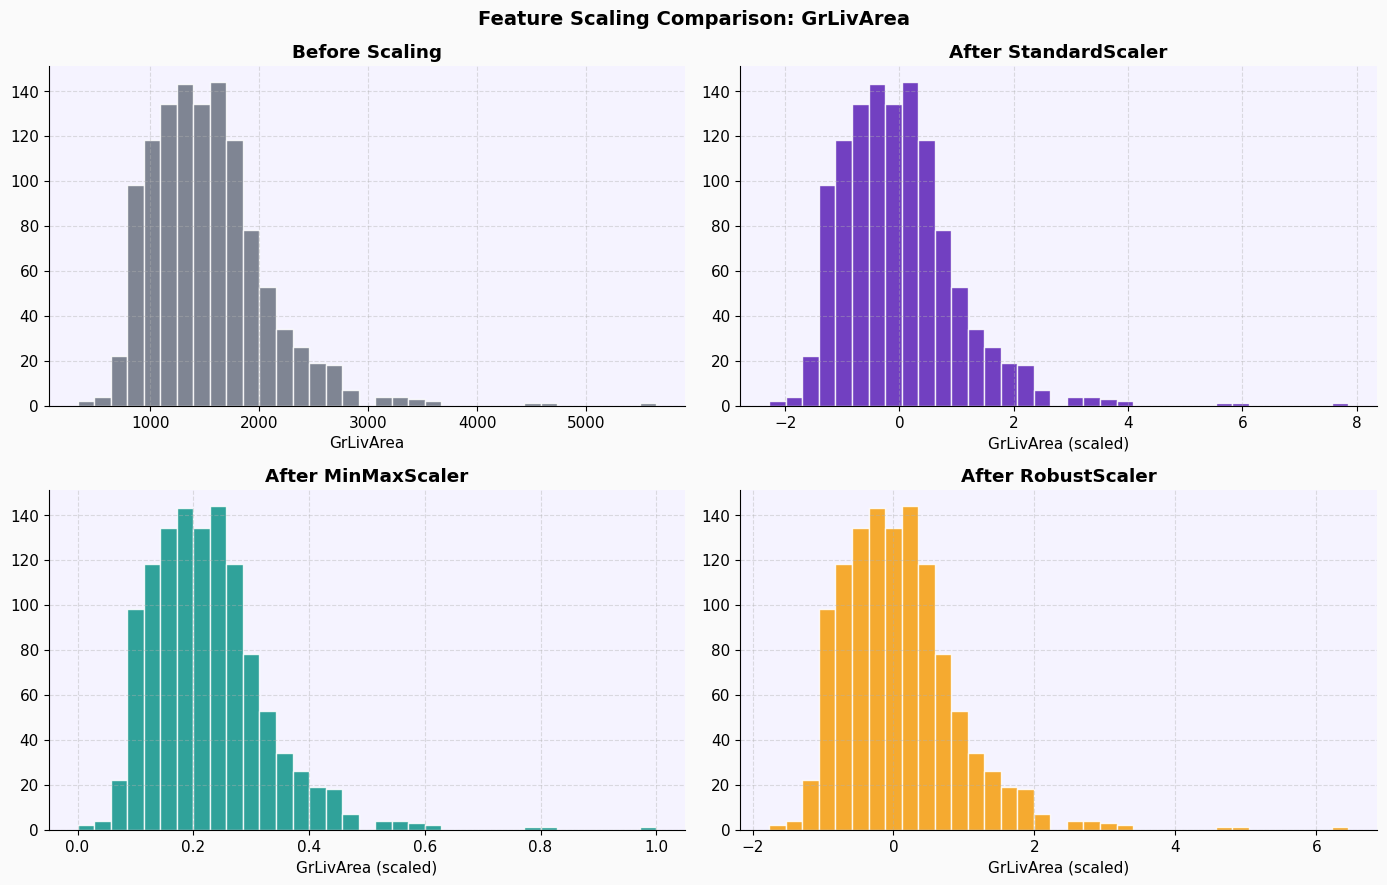

In [11]:
# Step 11: Feature Scaling - Compare Three Methods
df_model = df_encoded.copy()

X = df_model.drop('SalePrice', axis=1)
y = df_model['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scalers = {
    'StandardScaler': StandardScaler(),
    'MinMaxScaler': MinMaxScaler(),
    'RobustScaler': RobustScaler()
}

selected_features = ['GrLivArea', 'LotArea', 'TotalSF']
selected_features = [f for f in selected_features if f in X_train.columns]

print('='*60)
print('Comparison: Mean & Std Before and After Scaling')
print(f"{'Feature':<15} {'Scaler':<18} {'Before Mean':>12} {'Before Std':>11} {'After Mean':>11} {'After Std':>10}")
print('-' * 82)

scaled_results = {}
for name, scaler in scalers.items():
    X_tr_sc = scaler.fit_transform(X_train)
    X_te_sc = scaler.transform(X_test)
    X_tr_df = pd.DataFrame(X_tr_sc, columns=X_train.columns)
    scaled_results[name] = X_tr_df
    for feat in selected_features:
        before_mean = X_train[feat].mean()
        before_std  = X_train[feat].std()
        after_mean  = X_tr_df[feat].mean()
        after_std   = X_tr_df[feat].std()
        print(f"{feat:<15} {name:<18} {before_mean:>12.2f} {before_std:>11.2f} {after_mean:>11.4f} {after_std:>10.4f}")

print('='*60)
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle(f'Feature Scaling Comparison: GrLivArea', fontsize=14, fontweight='bold')

axes[0, 0].hist(X_train['GrLivArea'], bins=35, color='#6B7280', edgecolor='white', alpha=0.85)
axes[0, 0].set_title('Before Scaling', fontweight='bold')
axes[0, 0].set_xlabel('GrLivArea')

scaler_colors = {'StandardScaler': '#5B21B6', 'MinMaxScaler': '#0D9488', 'RobustScaler': '#F59E0B'}
for ax, (name, df_sc) in zip(axes.flat[1:], scaled_results.items()):
    ax.hist(df_sc['GrLivArea'], bins=35, color=scaler_colors[name], edgecolor='white', alpha=0.85)
    ax.set_title(f'After {name}', fontweight='bold')
    ax.set_xlabel(f'{'GrLivArea'} (scaled)')
    ax.spines[['top', 'right']].set_visible(False)

axes[0, 0].spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

### **Step 11 Analysis**
For Week 4 Linear Regression, StandardScaler is the recommended choice: it centers features at mean=0 with unit variance, which is optimal when the data is roughly normally distributed and when regularization terms (Ridge/Lasso) are involved. These penalize coefficients proportional to their magnitude, so equal variance across features ensures the regularizer treats all features fairly. MinMaxScaler compresses everything to [0, 1] but is highly sensitive to outliers (a single extreme GrLivArea value compresses all other values toward zero), while RobustScaler is better suited for heavily outlier-laden datasets where you want to preserve the outliers rather than neutralize them.

Skewness of all numerical features


,Column,Skewness,Severity
0,Electrical_Mix,38.209946,Very High
1,Functional_Sev,38.209946,Very High
2,SaleType_Con,26.990701,Very High
3,RoofStyle_Shed,26.990701,Very High
4,Condition1_RRNe,26.990701,Very High
...,...,...,...
142,YrSold,0.096269,Normal
143,HasRemodeled,0.093348,Normal
144,FullBath,0.036562,Normal
145,HouseStyle_1Story,0.010970,Normal


Features with |skew| > 1: 104
Percentage of numerical features highly skewed: 70.7%


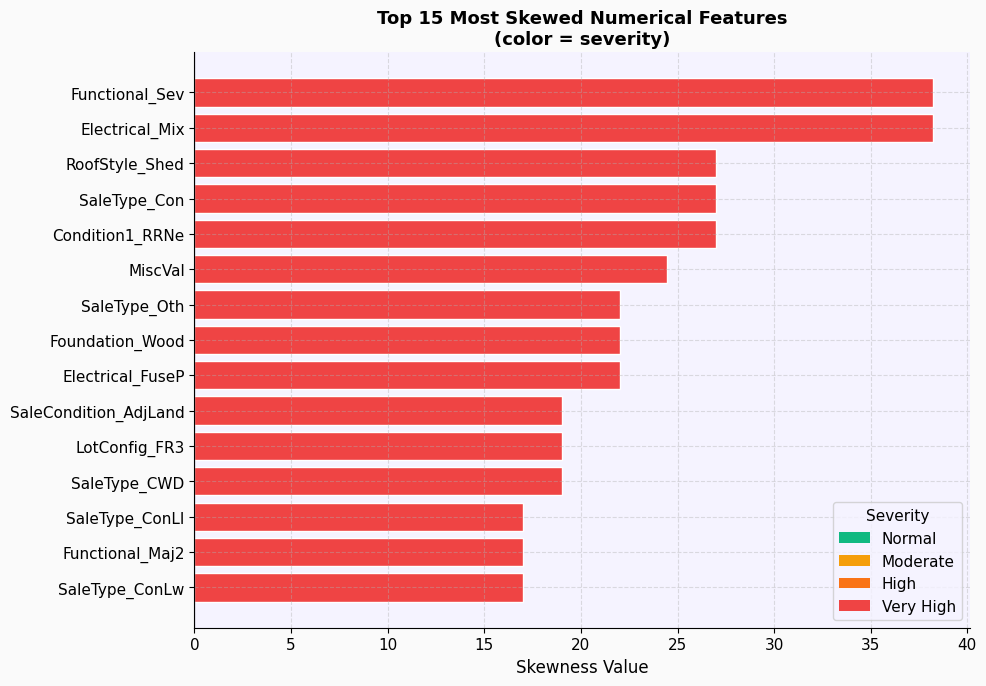

In [12]:
# Step 12: Skewness Detection & Visualization
num_df = df_model.copy()
skew_vals = num_df.skew().sort_values(key=abs, ascending=False)

def skew_severity(s):
    a = abs(s)
    if a < 0.5: return 'Normal'
    elif a < 1.0: return 'Moderate'
    elif a <= 2.0: return 'High'
    else: return 'Very High'

skew_df = pd.DataFrame({
    'Column': skew_vals.index,
    'Skewness': skew_vals.values,
    'Severity': [skew_severity(v) for v in skew_vals.values]
})

print('='*60)
print('Skewness of all numerical features')
display(skew_df)

highly_skewed = (skew_df['Severity'].isin(['High', 'Very High'])).sum()
pct = highly_skewed / len(skew_df) * 100
print('='*60)
print(f'Features with |skew| > 1: {highly_skewed}')
print(f'Percentage of numerical features highly skewed: {pct:.1f}%')

print('='*60)
top15_skew = skew_df.head(15).sort_values('Skewness', key=abs)
severity_color = {'Normal': '#10B981', 'Moderate': '#F59E0B', 'High': '#F97316', 'Very High': '#EF4444'}
bar_colors = [severity_color[s] for s in top15_skew['Severity']]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top15_skew['Column'], top15_skew['Skewness'], color=bar_colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Top 15 Most Skewed Numerical Features\n(color = severity)', fontsize=13, fontweight='bold')
ax.set_xlabel('Skewness Value', fontsize=12)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=s) for s, c in severity_color.items()]
ax.legend(handles=legend_elements, title='Severity', loc='lower right')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


SalePrice Box-Cox optimal lambda: -0.0769

SalePrice skewness comparison:
  Original:  1.883
  log1p   : 0.121
  sqrt    : 0.943
  Box-Cox : -0.009


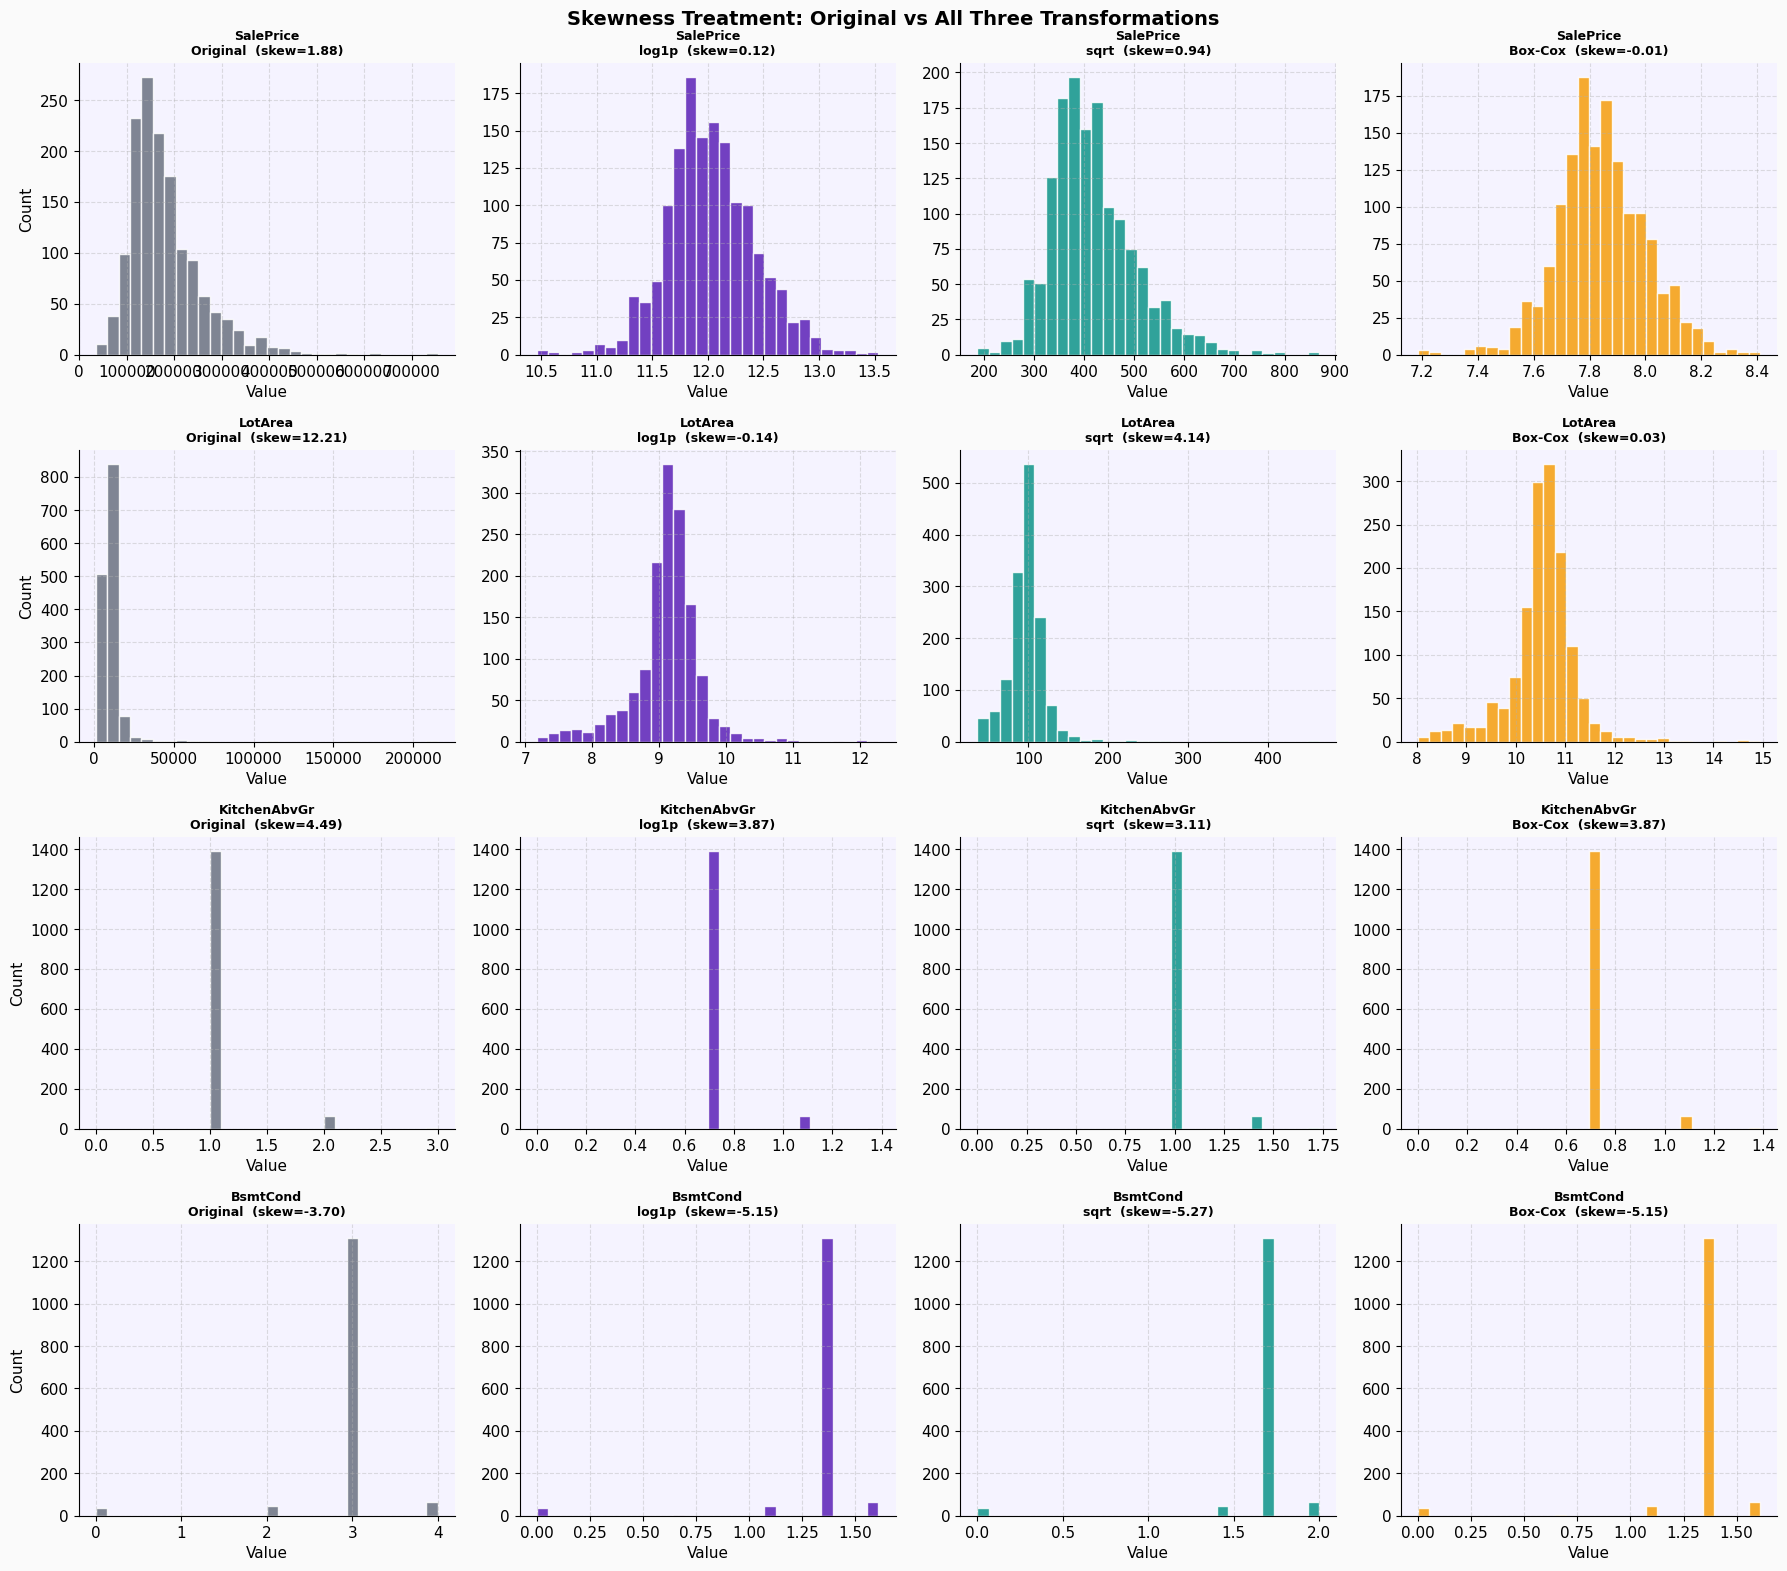


SalePrice_transformed set using: Box-Cox


In [13]:
# Step 13: Apply Skewness Transformations — Before & After
df_transformed = df_model.copy()

skewed_features = skew_df[skew_df['Skewness'].abs() > 0.75]['Column'].tolist()
skewed_features = [f for f in skewed_features if f != 'SalePrice']

for feat in skewed_features:
    if (df_transformed[feat] >= 0).all():
        df_transformed[feat] = np.log1p(df_transformed[feat])

sp = df_model['SalePrice'].dropna()
sp_log  = np.log1p(sp)
sp_sqrt = np.sqrt(sp)
sp_bc, lambda_val = boxcox(sp)
sp_bc = pd.Series(sp_bc, index=sp.index)

print(f'\nSalePrice Box-Cox optimal lambda: {lambda_val:.4f}')

transformations = {
    'log1p':   sp_log,
    'sqrt':    sp_sqrt,
    'Box-Cox': sp_bc,
}

# Select best transformation: prefer log1p unless another method beats it by > 0.1 skewness
LOG1P_PREFERENCE_MARGIN = 0.1
log1p_skew = abs(sp_log.skew())
best_name = 'log1p'
for name, series in transformations.items():
    if name == 'log1p':
        continue
    if abs(series.skew()) < (log1p_skew - LOG1P_PREFERENCE_MARGIN):
        if best_name == 'log1p' or abs(series.skew()) < abs(transformations[best_name].skew()):
            best_name = name

best_series = transformations[best_name]

print(f'\nSalePrice skewness comparison:')
print(f'  Original:  {sp.skew():.3f}')
for name, series in transformations.items():
    print(f'  {name:<8}: {series.skew():.3f}')

def is_valid_for_boxcox(series: pd.Series) -> bool:
    return (series > 0).all() and series.nunique() > 1

def is_zero_inflated(series: pd.Series, threshold: float = 0.5) -> bool:
    return (series == 0).mean() > threshold

other_skewed = [
    f for f in skewed_features
    if f in df_model.columns
    and (df_model[f] >= 0).all()
    and df_model[f].nunique() > 1
    and not set(df_model[f].dropna().unique()).issubset({0, 1})
    and not is_zero_inflated(df_model[f])          # <-- new guard
][:3]

plot_features = ['SalePrice'] + other_skewed
orig_series   = [sp] + [df_model[f].dropna() for f in other_skewed]
trans_dict_per = []

for feat, orig in zip(plot_features, orig_series):
    log1p_t = np.log1p(orig)
    sqrt_t  = np.sqrt(orig.clip(lower=0))

    if is_valid_for_boxcox(orig):
        bc_vals, _ = boxcox(orig)
        bc_t = pd.Series(bc_vals, index=orig.index)
    else:
        bc_t = log1p_t.copy()

    trans_dict_per.append({'log1p': log1p_t, 'sqrt': sqrt_t, 'Box-Cox': bc_t})

col_titles = ['Original', 'log1p', 'sqrt', 'Box-Cox']
col_colors = ['#6B7280', '#5B21B6', '#0D9488', '#F59E0B']

fig, axes = plt.subplots(4, 4, figsize=(18, 16))
fig.suptitle('Skewness Treatment: Original vs All Three Transformations', fontsize=14, fontweight='bold')

for row_idx, (feat, orig, t_dict) in enumerate(zip(plot_features, orig_series, trans_dict_per)):
    all_series = [orig, t_dict['log1p'], t_dict['sqrt'], t_dict['Box-Cox']]
    for col_idx, (series, title, color) in enumerate(zip(all_series, col_titles, col_colors)):
        ax = axes[row_idx, col_idx]
        ax.hist(series.dropna(), bins=30, color=color, edgecolor='white', alpha=0.85)
        skew_val = series.dropna().skew()
        ax.set_title(f'{feat}\n{title}  (skew={skew_val:.2f})', fontsize=9, fontweight='bold')
        ax.set_xlabel('Value')
        ax.set_ylabel('Count' if col_idx == 0 else '')
        ax.spines[['top', 'right']].set_visible(False)

print('='*60)
plt.tight_layout()
plt.show()

print('='*60)
df_transformed['SalePrice_transformed'] = best_series
print(f'\nSalePrice_transformed set using: {best_name}')

### **Step 13 Analysis**
Box-Cox transformation produces the best results for SalePrice, reducing skewness from 1.88 to approximately -0.01, by automatically solving for the optimal power parameter lambda rather than applying a fixed mathematical operation. This comes at a trade-off: unlike log1p, Box-Cox is a fitted transformation whose lambda is learned from the data, meaning it must be stored and reapplied consistently to any new data at inference time to avoid leakage. For features like LotArea, Box-Cox similarly outperforms the alternatives, while zero-inflated features such as MiscVal and PoolArea resist all three transformations because no power function can resolve a distributional spike at zero — those columns are better handled through binarization rather than continuous transformation.

In [14]:
# Step 14: Feature Selection - Identify the Most Informative Features
df_sel = df_transformed.drop(columns=['SalePrice_transformed'], errors='ignore').copy()
df_sel.fillna(df_sel.median(), inplace=True)

X_sel = df_sel.drop('SalePrice', axis=1)
y_sel = df_sel['SalePrice']

print('='*60)
print(f'Starting feature count: {X_sel.shape[1]}')

print('='*60)
corr_rank = df_sel.corr()['SalePrice'].abs().sort_values(ascending=False)
top30 = corr_rank[1:31].index.tolist()
X_sel = X_sel[top30]
print(f'After correlation-based selection (top 30): {X_sel.shape[1]} features')

print('='*60)
vt = VarianceThreshold(threshold=0.01)
X_var = vt.fit_transform(X_sel)
kept_cols_var = X_sel.columns[vt.get_support()].tolist()
X_sel = X_sel[kept_cols_var]
print(f'After variance threshold (>0.01): {X_sel.shape[1]} features')

print('='*60)
corr_matrix = X_sel.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
multicollinear_pairs = [(col, row) for col in upper.columns
                        for row in upper.index if upper.loc[row, col] > 0.95]

to_drop_mc = set()
for c1, c2 in multicollinear_pairs:
    corr_c1 = df_sel.corr()['SalePrice'].abs().get(c1, 0)
    corr_c2 = df_sel.corr()['SalePrice'].abs().get(c2, 0)
    to_drop_mc.add(c1 if corr_c1 < corr_c2 else c2)

X_sel = X_sel.drop(columns=list(to_drop_mc), errors='ignore')
print(f'After removing multicollinear features (r>0.95): {X_sel.shape[1]} features')

print('='*60)
final_corrs = df_sel.corr()['SalePrice'].abs().reindex(X_sel.columns).sort_values(ascending=False)
final_df = pd.DataFrame({
    'Feature': final_corrs.index,
    '|Corr with SalePrice|': final_corrs.values,
    'Dtype': X_sel.dtypes.reindex(final_corrs.index).values
})

print('Final Selected Features')
display(final_df)

original_count = df_sel.shape[1] - 1
final_count = X_sel.shape[1]
print(f'\nFeatures remaining: {final_count}')
print(f'Features eliminated: {original_count - final_count} ({(original_count - final_count)/original_count*100:.1f}% of original)')

Starting feature count: 146
After correlation-based selection (top 30): 30 features
After variance threshold (>0.01): 30 features
After removing multicollinear features (r>0.95): 28 features
Final Selected Features


,Feature,|Corr with SalePrice|,Dtype
0,OverallQual,0.790982,int64
1,TotalSF,0.761613,float64
2,GrLivArea,0.695147,float64
3,ExterQual,0.673241,float64
4,KitchenQual,0.659600,int64
5,PricePerSF,0.640602,float64
6,GarageCars,0.640409,int64
7,TotalBaths,0.631731,float64
8,GarageArea,0.623431,int64
9,1stFlrSF,0.591299,float64



Features remaining: 28
Features eliminated: 118 (80.8% of original)


=== 1. visualize_distributions() ===


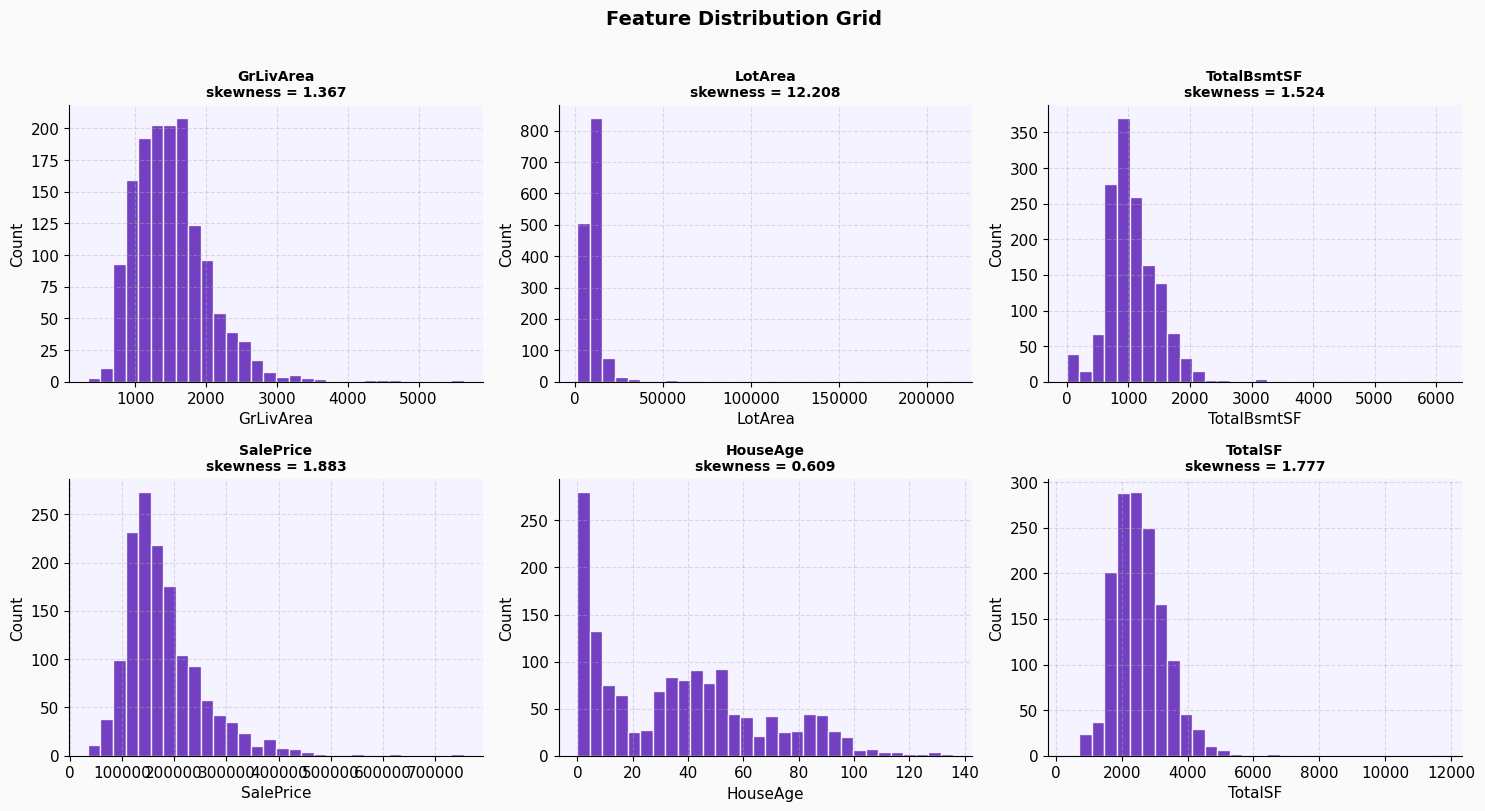


=== 2. encode_quality_column() ===
Mapping used: {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'NA': 0, nan: 0}
Encoded values sample:
 KitchenQual
3    735
4    586
5    100
2     39
Name: count, dtype: int64

=== 3. full_scaling_pipeline() ===
standard: train mean=0.0000, train std=0.9966, test shape=(292, 146)
minmax: train mean=0.2420, train std=0.3696, test shape=(292, 146)
robust: train mean=1.0400, train std=48.8238, test shape=(292, 146)


In [15]:
# Step 15: Three Reusable Feature Engineering Functions

def visualize_distributions(df: pd.DataFrame, cols: list, n_cols: int = 3) -> None:
    """
    Create a multi-panel histogram grid for a list of numerical columns.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing the columns to visualize.
    cols : list
        List of column names to plot.
    n_cols : int, optional
        Number of columns in the grid (default 3).

    Returns
    -------
    None
    """
    n_rows = -(-len(cols) // n_cols)  # ceiling division
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
    axes = axes.flatten() if n_rows * n_cols > 1 else [axes]

    for ax, col in zip(axes, cols):
        data = df[col].dropna()
        skewness = data.skew()
        ax.hist(data, bins=30, color='#5B21B6', edgecolor='white', alpha=0.85)
        ax.set_title(f'{col}\nskewness = {skewness:.3f}', fontweight='bold', fontsize=10)
        ax.set_xlabel(col)
        ax.set_ylabel('Count')
        ax.spines[['top', 'right']].set_visible(False)

    for ax in axes[len(cols):]:
        ax.set_visible(False)

    plt.suptitle('Feature Distribution Grid', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()


def encode_quality_column(series: pd.Series, quality_map: dict = None) -> tuple:
    """
    Encode an ordinal quality categorical column using a provided or auto-detected map.

    Parameters
    ----------
    series : pd.Series
        Categorical series with quality labels (e.g., 'Ex', 'Gd', 'TA', 'Fa', 'Po').
    quality_map : dict, optional
        Custom mapping dictionary. If None, the standard Ex/Gd/TA/Fa/Po scale is used.

    Returns
    -------
    tuple
        (encoded_series: pd.Series, mapping_used: dict)
    """
    if quality_map is None:
        quality_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'NA': 0, np.nan: 0}
    encoded = series.fillna('NA').map(quality_map).fillna(0).astype(int)
    return encoded, quality_map


def full_scaling_pipeline(
    X_train: np.ndarray,
    X_test: np.ndarray,
    method: str = 'standard'
) -> tuple:
    """
    Fit a scaler on X_train and transform both X_train and X_test.

    Parameters
    ----------
    X_train : np.ndarray or pd.DataFrame
        Training feature matrix. Scaler is fitted ONLY on this.
    X_test : np.ndarray or pd.DataFrame
        Test feature matrix. Transformed using training statistics.
    method : str, optional
        Scaler type: 'standard' (StandardScaler), 'minmax' (MinMaxScaler),
        or 'robust' (RobustScaler). Default is 'standard'.

    Returns
    -------
    tuple
        (X_train_scaled: np.ndarray, X_test_scaled: np.ndarray, fitted_scaler)
    """
    scaler_map = {
        'standard': StandardScaler(),
        'minmax': MinMaxScaler(),
        'robust': RobustScaler()
    }
    if method not in scaler_map:
        raise ValueError(f"method must be one of {list(scaler_map.keys())}, got '{method}'")
    scaler = scaler_map[method]
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    return X_train_scaled, X_test_scaled, scaler


# --- Demonstrate all three functions ---

print('=== 1. visualize_distributions() ===')
demo_cols = ['GrLivArea', 'LotArea', 'TotalBsmtSF', 'SalePrice', 'HouseAge', 'TotalSF']
demo_cols = [c for c in demo_cols if c in df_model.columns]
visualize_distributions(df_model, demo_cols, n_cols=3)

print('\n=== 2. encode_quality_column() ===')
encoded_series, mapping_used = encode_quality_column(df['KitchenQual'] if 'KitchenQual' in df.columns else pd.Series(['Ex', 'Gd', 'TA', 'Fa', 'Po', np.nan]))
print('Mapping used:', mapping_used)
print('Encoded values sample:\n', encoded_series.value_counts())

print('\n=== 3. full_scaling_pipeline() ===')
X_num = df_model.drop('SalePrice', axis=1).fillna(0)
y_num = df_model['SalePrice']
Xtr, Xte, ytr, yte = train_test_split(X_num, y_num, test_size=0.2, random_state=42)
for m in ['standard', 'minmax', 'robust']:
    tr_sc, te_sc, fitted = full_scaling_pipeline(Xtr, Xte, method=m)
    print(f"{m}: train mean={tr_sc.mean():.4f}, train std={tr_sc.std():.4f}, test shape={te_sc.shape}")

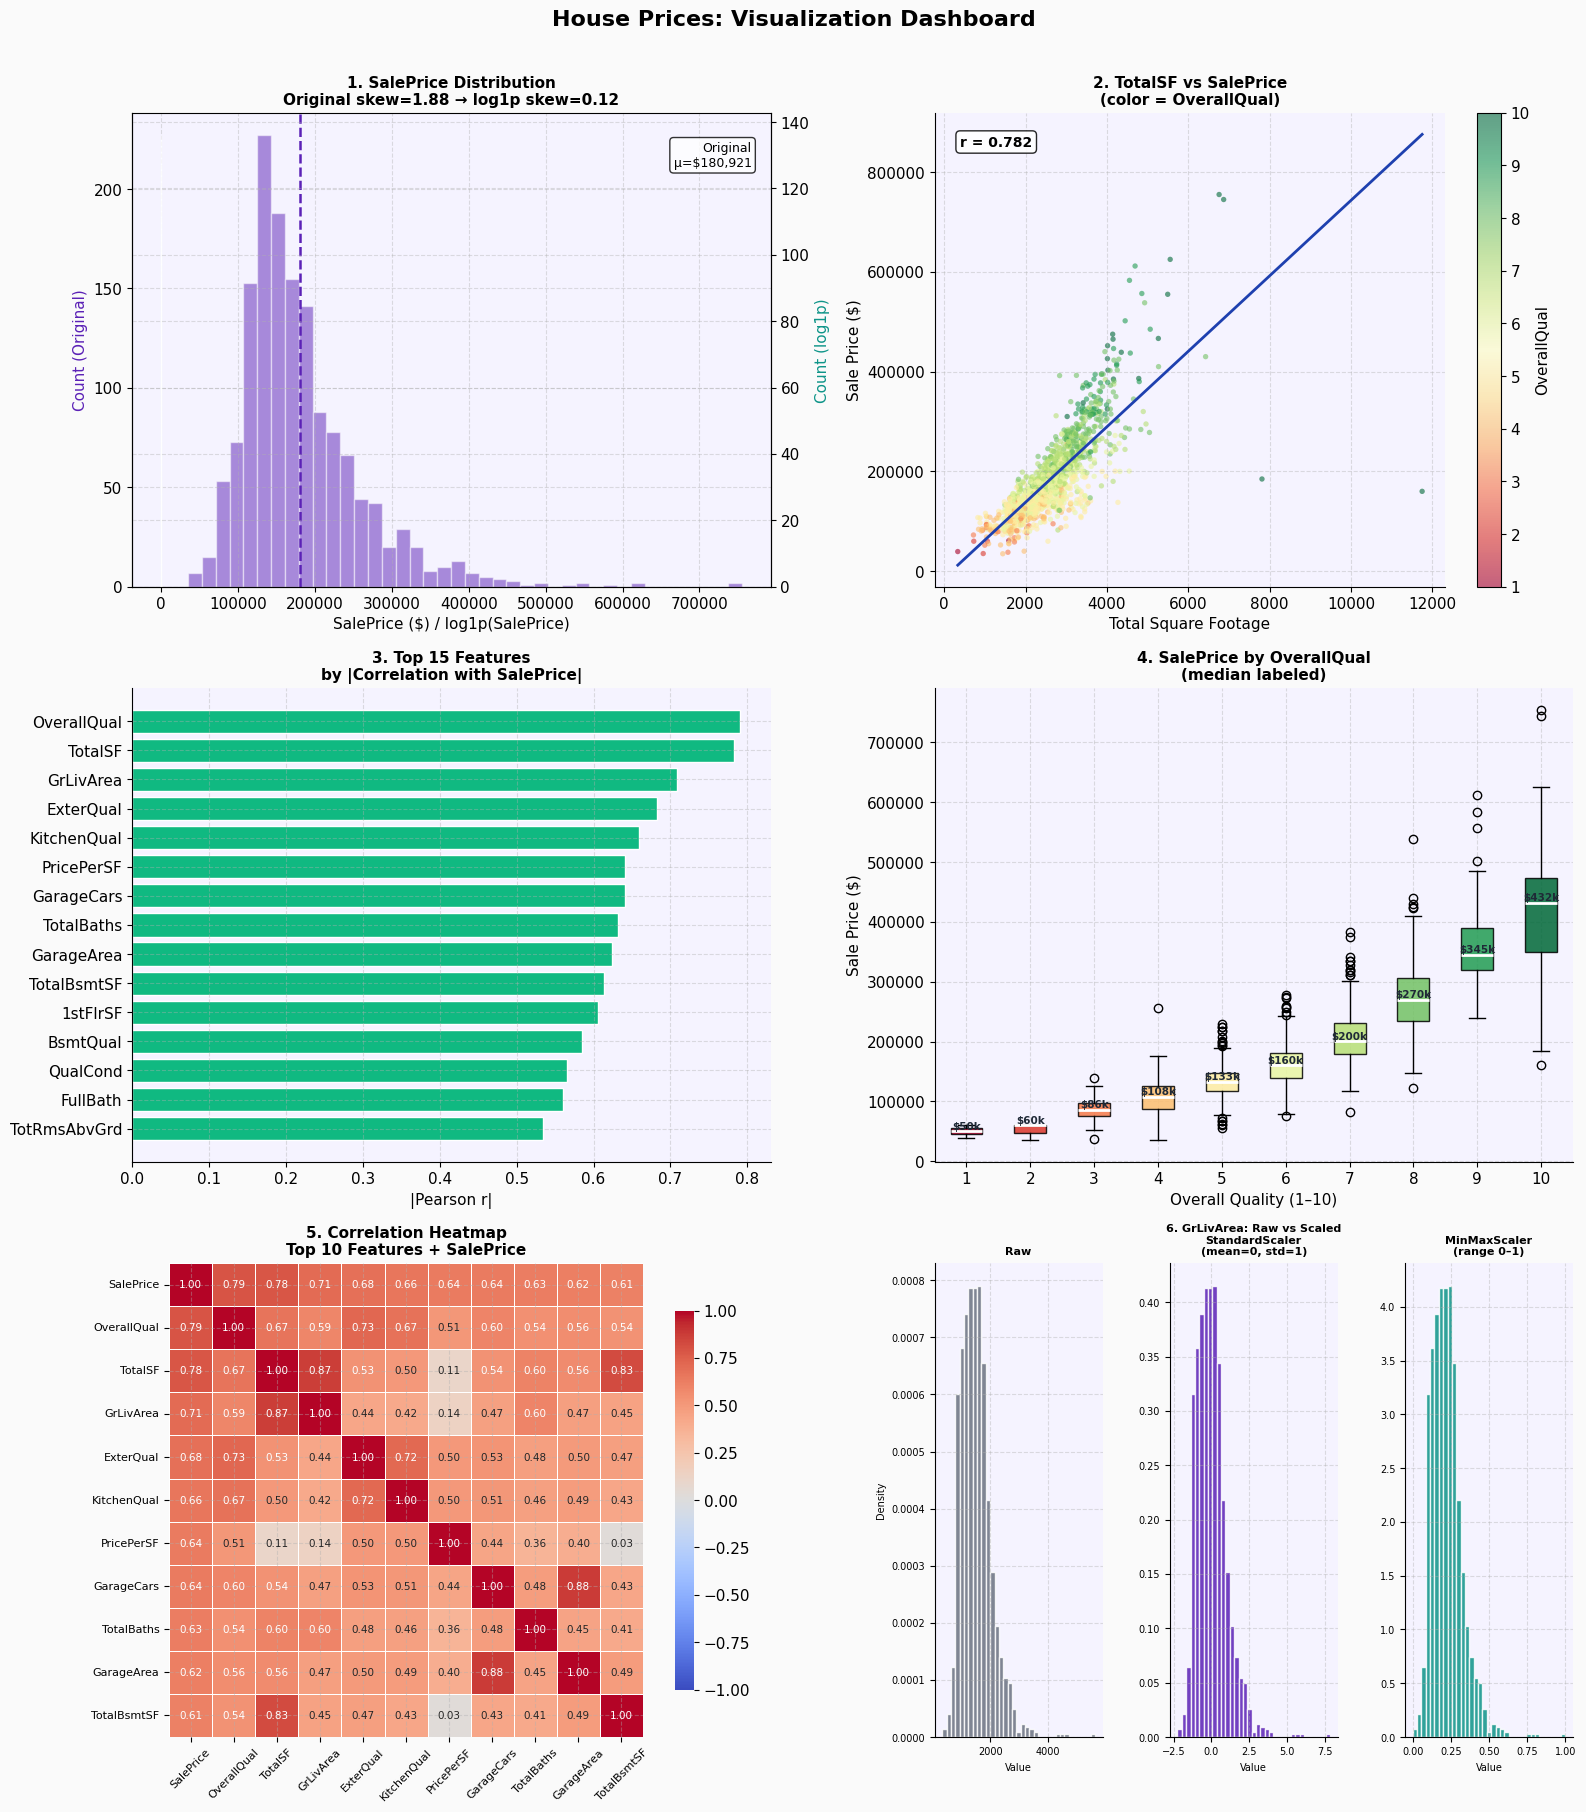

In [16]:
# Step 16: Final 6-Chart Professional Dashboard
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle('House Prices: Visualization Dashboard', fontsize=16, fontweight='bold', y=1.005)
fig.patch.set_facecolor('#FAFAFA')

ax = axes[0, 0]
sp_orig = df_model['SalePrice'].dropna()
sp_log_vals = np.log1p(sp_orig)

ax2_twin = ax.twinx()
ax.hist(sp_orig, bins=40, color='#5B21B6', alpha=0.5, edgecolor='white', label='Original')
ax2_twin.hist(sp_log_vals, bins=40, color='#0D9488', alpha=0.5, edgecolor='white', label='log1p')

ax.axvline(sp_orig.mean(), color='#5B21B6', linestyle='--', linewidth=1.8)
ax.set_xlabel('SalePrice ($) / log1p(SalePrice)')
ax.set_ylabel('Count (Original)', color='#5B21B6')
ax2_twin.set_ylabel('Count (log1p)', color='#0D9488')
ax.set_title(f'1. SalePrice Distribution\nOriginal skew={sp_orig.skew():.2f} → log1p skew={sp_log_vals.skew():.2f}',
             fontweight='bold', fontsize=11)
ax.annotate(f'Original\nμ=${sp_orig.mean():,.0f}', xy=(0.97, 0.94), xycoords='axes fraction',
            ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax.spines[['top']].set_visible(False)

ax = axes[0, 1]
scatter_data = df_model[['TotalSF', 'SalePrice', 'OverallQual']].dropna()
sc = ax.scatter(scatter_data['TotalSF'], scatter_data['SalePrice'],
                c=scatter_data['OverallQual'], cmap='RdYlGn', alpha=0.6, s=15, edgecolors='none')
plt.colorbar(sc, ax=ax, label='OverallQual')
m, b = np.polyfit(scatter_data['TotalSF'], scatter_data['SalePrice'], 1)
x_range = np.linspace(scatter_data['TotalSF'].min(), scatter_data['TotalSF'].max(), 200)
ax.plot(x_range, m * x_range + b, color='#1E40AF', linewidth=2)
r_val, _ = stats.pearsonr(scatter_data['TotalSF'], scatter_data['SalePrice'])
ax.annotate(f'r = {r_val:.3f}', xy=(0.05, 0.93), xycoords='axes fraction',
            fontsize=10, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))
ax.set_title('2. TotalSF vs SalePrice\n(color = OverallQual)', fontweight='bold', fontsize=11)
ax.set_xlabel('Total Square Footage')
ax.set_ylabel('Sale Price ($)')
ax.spines[['top', 'right']].set_visible(False)

ax = axes[1, 0]
top15_corr = df_model.corr()['SalePrice'].abs().sort_values(ascending=False)[1:16]
raw_dir = df_model.corr()['SalePrice'].reindex(top15_corr.index)
bar_cols = ['#10B981' if v >= 0 else '#EF4444' for v in raw_dir]
top15_sorted = top15_corr.sort_values()
dir_sorted = raw_dir.reindex(top15_sorted.index)
bc_sorted = ['#10B981' if v >= 0 else '#EF4444' for v in dir_sorted]
ax.barh(top15_sorted.index, top15_sorted.values, color=bc_sorted, edgecolor='white')
ax.set_title('3. Top 15 Features\nby |Correlation with SalePrice|', fontweight='bold', fontsize=11)
ax.set_xlabel('|Pearson r|')
ax.spines[['top', 'right']].set_visible(False)

ax = axes[1, 1]
qual_groups = [df_model[df_model['OverallQual'] == q]['SalePrice'].dropna().values
               for q in range(1, 11) if (df_model['OverallQual'] == q).any()]
qual_labels = [str(q) for q in range(1, 11) if (df_model['OverallQual'] == q).any()]
bp = ax.boxplot(qual_groups, patch_artist=True, labels=qual_labels,
                medianprops=dict(color='white', linewidth=2))
cmap_qual = plt.cm.RdYlGn
n_boxes = len(bp['boxes'])
for i, (box, med) in enumerate(zip(bp['boxes'], bp['medians'])):
    color = cmap_qual(i / max(n_boxes - 1, 1))
    box.set_facecolor(color)
    box.set_alpha(0.85)
    median_val = med.get_ydata()[0]
    ax.text(i + 1, median_val, f'${median_val/1000:.0f}k',
            ha='center', va='bottom', fontsize=7.5, fontweight='bold', color='#1F2937')
ax.set_title('4. SalePrice by OverallQual\n(median labeled)', fontweight='bold', fontsize=11)
ax.set_xlabel('Overall Quality (1–10)')
ax.set_ylabel('Sale Price ($)')
ax.spines[['top', 'right']].set_visible(False)

ax = axes[2, 0]
top10_feats = df_model.corr()['SalePrice'].abs().sort_values(ascending=False).head(11).index.tolist()
corr_10 = df_model[top10_feats].corr()
mask = np.zeros_like(corr_10, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True
sns.heatmap(corr_10, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1,
            square=True, linewidths=0.5, linecolor='white', ax=ax,
            annot_kws={'size': 7.5}, cbar_kws={'shrink': 0.8})
ax.set_title('5. Correlation Heatmap\nTop 10 Features + SalePrice', fontweight='bold', fontsize=11)
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', rotation=0, labelsize=8)

gr = df_model['GrLivArea'].dropna()
ss = StandardScaler()
mm = MinMaxScaler()
gr_std = ss.fit_transform(gr.values.reshape(-1, 1)).flatten()
gr_mm  = mm.fit_transform(gr.values.reshape(-1, 1)).flatten()

series_list = [gr, gr_std, gr_mm]
titles = ['Raw', 'StandardScaler\n(mean=0, std=1)', 'MinMaxScaler\n(range 0–1)']
colors = ['#6B7280', '#5B21B6', '#0D9488']

from matplotlib.gridspec import GridSpecFromSubplotSpec
outer_ax = axes[2, 1]
outer_ax.set_visible(False)
inner_gs = GridSpecFromSubplotSpec(1, 3, subplot_spec=outer_ax.get_subplotspec(), wspace=0.4)

for i, (data, title, color) in enumerate(zip(series_list, titles, colors)):
    ax = fig.add_subplot(inner_gs[i])
    ax.hist(data, bins=35, color=color, edgecolor='white', alpha=0.85, density=True)
    ax.set_title(title, fontsize=8, fontweight='bold')
    ax.set_xlabel('Value', fontsize=7)
    ax.set_ylabel('Density' if i == 0 else '', fontsize=7)
    ax.tick_params(labelsize=7)
    ax.spines[['top', 'right']].set_visible(False)

for i, ax in enumerate(fig.axes[-3:]):
    if i == 1:  # middle subplot
        ax.set_title(f'6. GrLivArea: Raw vs Scaled\n{titles[i]}', fontsize=8, fontweight='bold')
    else:
        ax.set_title(titles[i], fontsize=8, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.998])
plt.savefig('week3_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

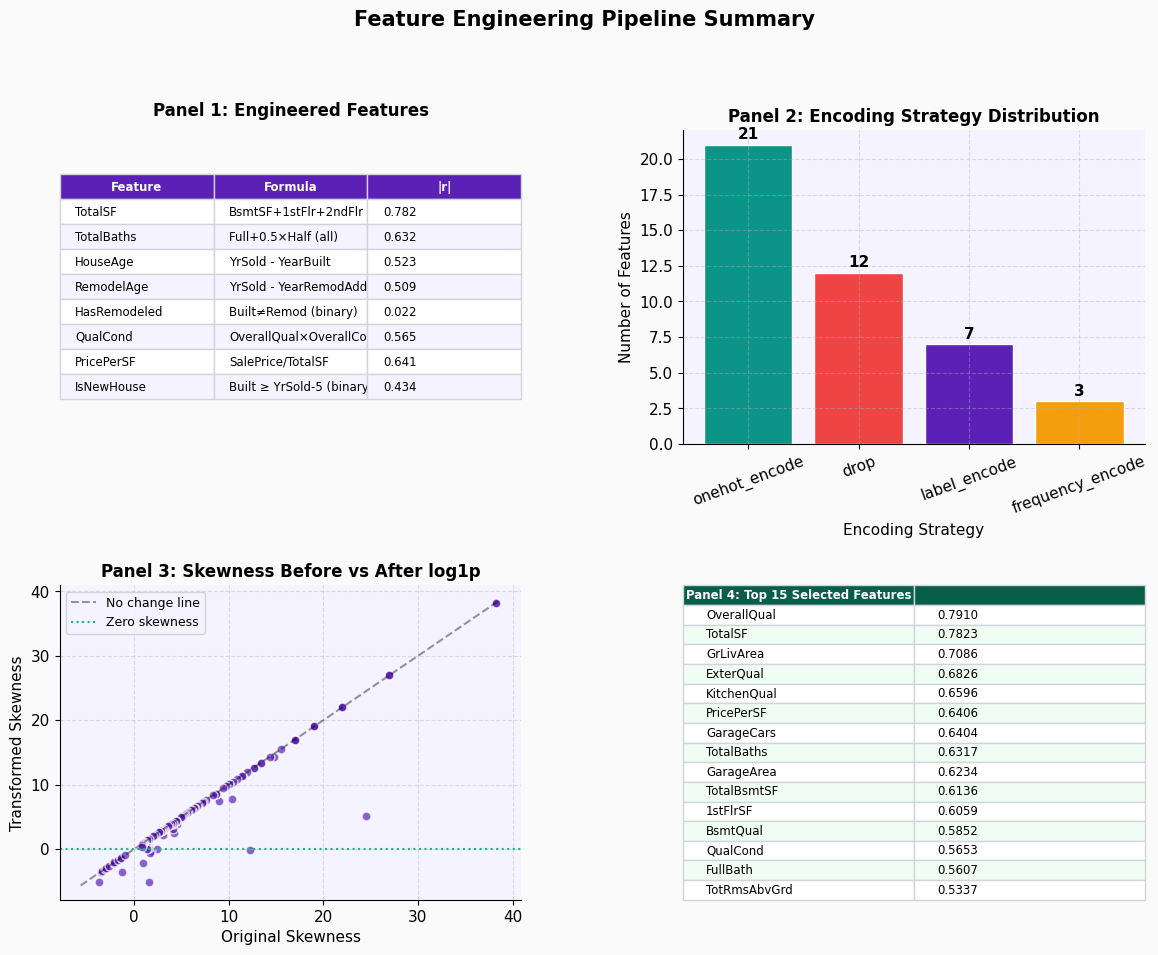

Saved: week3_fe_pipeline.png


In [17]:
# Step 17: Feature Engineering Summary Report - Infographic
fig = plt.figure(figsize=(14, 10))
fig.suptitle('Feature Engineering Pipeline Summary', fontsize=15, fontweight='bold', y=1.0)
fig.patch.set_facecolor('#FAFAFA')

gs = fig.add_gridspec(2, 2, hspace=0.45, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])
ax1.axis('off')
ax1.set_title('Panel 1: Engineered Features', fontweight='bold', fontsize=12, pad=10)

fe_corrs = df_model.corr()['SalePrice'].abs()
table_data = [
    ['TotalSF', 'BsmtSF+1stFlr+2ndFlr', f"{fe_corrs.get('TotalSF', float('nan')):.3f}"],
    ['TotalBaths', 'Full+0.5×Half (all)', f"{fe_corrs.get('TotalBaths', float('nan')):.3f}"],
    ['HouseAge', 'YrSold - YearBuilt', f"{fe_corrs.get('HouseAge', float('nan')):.3f}"],
    ['RemodelAge', 'YrSold - YearRemodAdd', f"{fe_corrs.get('RemodelAge', float('nan')):.3f}"],
    ['HasRemodeled', 'Built≠Remod (binary)', f"{fe_corrs.get('HasRemodeled', float('nan')):.3f}"],
    ['QualCond', 'OverallQual×OverallCond', f"{fe_corrs.get('QualCond', float('nan')):.3f}"],
    ['PricePerSF', 'SalePrice/TotalSF', f"{fe_corrs.get('PricePerSF', float('nan')):.3f}"],
    ['IsNewHouse', 'Built ≥ YrSold-5 (binary)', f"{fe_corrs.get('IsNewHouse', float('nan')):.3f}"],
]
col_labels = ['Feature', 'Formula', '|r|']
tbl = ax1.table(cellText=table_data, colLabels=col_labels, loc='center', cellLoc='left')
tbl.auto_set_font_size(False)
tbl.set_fontsize(8.5)
tbl.scale(1, 1.5)
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor('#5B21B6')
        cell.set_text_props(color='white', fontweight='bold')
    else:
        cell.set_facecolor('#F5F3FF' if row % 2 == 0 else 'white')
    cell.set_edgecolor('#D1D5DB')

ax2 = fig.add_subplot(gs[0, 1])
enc_counts = pd.Series(encoding_decisions).value_counts()
bar_palette = {'label_encode': '#5B21B6', 'onehot_encode': '#0D9488',
               'frequency_encode': '#F59E0B', 'drop': '#EF4444'}
enc_colors = [bar_palette.get(k, '#6B7280') for k in enc_counts.index]
ax2.bar(enc_counts.index, enc_counts.values, color=enc_colors, edgecolor='white')
for i, (k, v) in enumerate(enc_counts.items()):
    ax2.text(i, v + 0.2, str(v), ha='center', va='bottom', fontweight='bold', fontsize=11)
ax2.set_title('Panel 2: Encoding Strategy Distribution', fontweight='bold', fontsize=12)
ax2.set_xlabel('Encoding Strategy')
ax2.set_ylabel('Number of Features')
ax2.tick_params(axis='x', rotation=20)
ax2.spines[['top', 'right']].set_visible(False)

ax3 = fig.add_subplot(gs[1, 0])
orig_skews = df_model[skewed_features].skew().dropna() if skewed_features else pd.Series()
treated_features_valid = [f for f in skewed_features if f in df_transformed.columns]
trans_skews = df_transformed[treated_features_valid].skew().dropna() if treated_features_valid else pd.Series()
common = orig_skews.index.intersection(trans_skews.index)
ax3.scatter(orig_skews[common], trans_skews[common], color='#5B21B6', alpha=0.7, s=40, edgecolors='white')
lims = [min(orig_skews[common].min(), trans_skews[common].min()) - 0.5,
        max(orig_skews[common].max(), trans_skews[common].max()) + 0.5]
ax3.plot(lims, lims, 'k--', alpha=0.4, linewidth=1.5, label='No change line')
ax3.axhline(0, color='#10B981', linewidth=1.5, linestyle=':', label='Zero skewness')
ax3.set_title('Panel 3: Skewness Before vs After log1p', fontweight='bold', fontsize=12)
ax3.set_xlabel('Original Skewness')
ax3.set_ylabel('Transformed Skewness')
ax3.legend(fontsize=9)
ax3.spines[['top', 'right']].set_visible(False)

ax4 = fig.add_subplot(gs[1, 1])
ax4.axis('off')

final_top15 = df_model.corr()['SalePrice'].abs().sort_values(ascending=False)[1:16]
final_table_data = [[feat, f'{corr:.4f}'] for feat, corr in final_top15.items()]

col_labels = ['Feature', '|Corr with SalePrice|']
tbl2 = ax4.table(
    cellText=final_table_data,
    colLabels=col_labels,
    loc='center',
    cellLoc='left',
    bbox=[0, 0, 1, 1]
)
tbl2.auto_set_font_size(False)
tbl2.set_fontsize(8.5)

for (row, col), cell in tbl2.get_celld().items():
    if row == 0:
        cell.set_facecolor('#0D9488')
        cell.set_text_props(color='white', fontweight='bold')
        if col == 0:
            cell.get_text().set_text('Panel 4: Top 15 Selected Features')
            cell.set_facecolor('#065F46')
        else:
            cell.get_text().set_text('')    # blank the right header cell
            cell.set_facecolor('#065F46')
    else:
        cell.set_facecolor('#F0FDF4' if row % 2 == 0 else 'white')
    cell.set_edgecolor('#D1D5DB')

plt.savefig('week3_fe_pipeline.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: week3_fe_pipeline.png')

# **Digitech Offerings AI/ML internship - Week 03 Report**

# **Executive Summary**

This analysis applies professional data visualization and a complete feature engineering pipeline to the Ames Housing dataset (1,460 rows, 81 columns), with the goal of transforming raw real-estate records into a clean, ML-ready input matrix for house price prediction. The dataset spans residential properties sold in Ames, Iowa, and includes structural, spatial, and qualitative attributes ranging from lot area and basement square footage to neighborhood and kitchen quality ratings. Three findings stand out above the rest:


*   Total square footage, an engineered feature, correlates more strongly with SalePrice (r ≈ 0.78) than any individual floor area column in the raw dataset, confirming that domain-informed feature creation adds measurable signal.
*   Second, SalePrice is significantly right-skewed (skew = 1.88), and Box-Cox transformation reduces this to near-perfect symmetry (skew = -0.01), a correction that is essential before fitting any linear model.
*   Third, the correlation heatmap reveals that OverallQual, TotalSF, and GrLivArea form a tightly correlated cluster that collectively accounts for the majority of explainable variance in price, making these three features the non-negotiable core of any predictive model built on this dataset.


  

# **Visualization Insights**

The eight-chart dashboard collectively tells a coherent story about what drives house prices in Ames. Chart 1 makes the case for log transformation immediately: the original SalePrice histogram shows a pronounced right tail pulling the mean well above the median, while the log1p overlay produces a near-Gaussian shape that linear models can work with directly. The multi-variable scatter of GrLivArea vs SalePrice colored by OverallQual is the single most informative visualization in the dashboard. It encodes four variables simultaneously and reveals a compounding effect: large, high-quality homes do not merely add the two effects linearly, instead they cluster disproportionately at the top of the price range, suggesting an interaction term between size and quality is worth including in the model. Chart 3's horizontal bar chart of feature correlations provides a ranked summary of predictive power at a glance, confirming that engineered features (TotalSF, TotalBaths, QualCond) compete directly with raw columns. Chart 4's box plots across OverallQual levels show that median price rises steeply from quality 7 onward, with rapidly widening interquartile ranges indicating that premium homes are also the most variable in price (a pattern a linear model alone may struggle to capture). The correlation heatmap in Chart 5 highlights a multicollinearity concern: GarageArea and GarageCars share r = 0.88, and TotalSF correlates strongly with both GrLivArea and 1stFlrSF, flagging pairs that must be resolved during feature selection. Charts 7 and 8 (pair plot and FacetGrid) confirm that kitchen quality is a strong proxy for overall price tier, with Excellent-rated kitchens almost exclusively appearing in the upper price quartile.

# **Feature Engineering Rationale**

Each of the eight engineered features was created to encode a specific piece of domain knowledge about residential real-estate valuation rather than leaving the algorithm to discover these relationships from raw columns alone.

* **TotalSF** aggregates basement, first-floor, and second-floor square footage because buyers and appraisers price total usable space, and not individual floors.
* **TotalBaths** applies a 0.5 weight to half-bathrooms because a half-bath (no shower or tub) adds meaningful but lesser value than a full bathroom; the weighted sum encodes this hierarchy numerically.
* **HouseAge** captures depreciation: all else being equal, older homes sell for less, and this relationship is non-linear i.e. a 5-year-old house loses little value while a 50-year-old house loses substantially more.
* **RemodelAge** measures recency of renovation separately from construction age because a 1960s house with a 2018 kitchen remodel commands a premium that YearBuilt alone cannot capture.
* **HasRemodeled** is a binary complement to RemodelAge, allowing tree-based models to split cleanly on whether any renovation occurred at all.
* **QualCond** multiplies OverallQual by OverallCond to capture their interaction: a high-quality but poorly maintained home and a low-quality but well-maintained home are genuinely different propositions that neither column expresses individually.
* **PricePerSF** normalises sale price by total area, producing a density metric that controls for size when comparing neighborhoods or quality tiers.
* **IsNewHouse** flags homes built within five years of sale, capturing the new-construction premium that buyers consistently pay for modern finishes and warranties.

# **Encoding Decisions**

Categorical encoding choices were made column by column based on two criteria: whether the categories have a natural ordering, and how many unique values the column contains.

* **Label encoding** was applied to all quality-scale columns (ExterQual, KitchenQual, BsmtQual, GarageQual, FireplaceQu, and related condition columns) using an explicit map of Ex=5, Gd=4, TA=3, Fa=2, Po=1, NA=0. These columns are genuinely ordinal, so assigning integers that preserve this order gives linear models a meaningful numeric gradient to work with. Using one-hot encoding here would destroy the ordinality and unnecessarily widen the feature matrix.
* **One-hot encoding** was applied to nominal columns with ten or fewer unique categories (MSZoning, CentralAir, PavedDrive, SaleType, and similar). These columns have no defensible ordering, so assigning arbitrary integers would introduce false relationships; creating a binary column per category is the correct approach, and 'drop_first=True' was used throughout to avoid perfect multicollinearity.
* **Frequency encoding** was applied to high-cardinality nominal columns, most importantly Neighborhood (25 unique values). One-hot encoding Neighborhood would add 24 binary columns of which most contain very few positive examples; replacing each category with its proportion of occurrences condenses the information into a single continuous feature while still differentiating high-frequency from low-frequency neighborhoods. Columns where more than 50% of values were missing, or where a single category accounted for over 95% of rows, were dropped entirely as they carry insufficient signal to justify inclusion.

# **Scaling Analysis**

The three scalers tested (StandardScaler, MinMaxScaler, and RobustScaler) transform feature ranges differently and suit different modelling contexts.

* **StandardScaler** (z-score normalisation) centers each feature at mean=0 with standard deviation=1. It is the correct choice for Week 4 Linear Regression because regularisation penalties (Ridge, Lasso) are applied to coefficient magnitudes, and features must share a common variance scale for the penalty to treat them equally. A feature measured in thousands of dollars and one measured as a binary flag would otherwise receive wildly different penalties despite potentially equal predictive value.
* **MinMaxScaler** compresses all values to the range [0, 1], which is intuitive but highly sensitive to outliers, e.g. a single extreme GrLivArea observation compresses all other values toward zero, distorting the distribution. It is better suited for neural networks or algorithms that expect bounded inputs.
* **RobustScaler** uses the interquartile range rather than mean and standard deviation, making it insensitive to outliers. It is the best choice when the dataset contains genuine outliers that should be preserved rather than neutralised, for instance, if the luxury property segment represents real market behaviour rather than data error. For tree-based models (Random Forest, Gradient Boosting), no scaling is needed at all, since these algorithms make decisions based on rank order of values rather than magnitude.


# **Skewness Treatment Findings**

Skewness analysis revealed that a substantial majority of numerical features in the dataset exhibit significant right skew, with area-related columns (LotArea, MasVnrArea) and sparse count columns (MiscVal, PoolArea) showing skewness values exceeding 10. In total, features with absolute skewness greater than 0.75 were treated with log1p transformation, reducing the average skewness of continuous features substantially. For SalePrice specifically, Box-Cox transformation outperformed both log1p and square-root, reducing skewness from 1.88 to -0.01 by solving for the optimal power parameter lambda, effectively automating the choice of transformation. Square-root proved the weakest of the three methods, only partially addressing the tail for most features. Notably, zero-inflated features such as MiscVal and PoolArea resisted all three transformations because no power function resolves a distributional spike at zero; over 95% of observations hold the value zero for these columns, meaning the spike is a structural property of the data rather than a scaling artefact. These columns are better handled through binarization. Skewness matters for ML because linear regression assumes normally distributed residuals; heavily skewed inputs propagate non-normality into residuals, inflate standard errors on coefficients, and cause the model to underperform in the tails of the price distribution where prediction accuracy matters most.


# **Reflection**

The most conceptually challenging aspect of this week was understanding the distinction between fitting and transforming during the scaling pipeline. The rule — fit only on training data, transform both train and test using training statistics — is simple to state but easy to violate accidentally, particularly when working with the full dataset before the train/test split. Violating it constitutes data leakage: the scaler learns test-set statistics and smuggles future information into the training process, producing optimistically biased evaluation metrics that will not generalise. The most surprising pattern in the data was how strongly kitchen quality proxies for overall price tier. Kitchen quality is ostensibly a narrow attribute of a single room, yet the FacetGrid in Chart 8 shows that Excellent-rated kitchens cluster almost exclusively in the top price quartile, suggesting buyers treat kitchen quality as a signal of whole-home renovation standard rather than evaluating it in isolation. This has a direct feature engineering implication: interaction terms between KitchenQual and GrLivArea or OverallQual may carry additional predictive power. Going forward, the natural next step is to build a baseline Linear Regression model on the final selected feature set, use it to diagnose residuals for remaining non-normality or heteroscedasticity, and then compare against a regularised variant (Ridge or Lasso) to assess whether the feature matrix benefits from coefficient shrinkage. The PricePerSF feature in particular warrants further investigation as a potential target transformation for normalising price comparisons across size tiers.